# Exploratory Data Analysis (EDA)
## E-commerce Online Retail — 2009–2011

**Project:** Cohort Analysis & Time Series Forecasting for LTV/ROMI Optimization  
**Dataset:** `online_retail_cleaned_full.csv` (~798K transactions, 5,362 customers)  
**Period:** December 2009 – December 2011

---

### Nội dung phân tích

| # | Section |
|---|--------|
| 1 | Setup & Data Loading |
| 2 | Tổng quan dữ liệu (Overview) |
| 3 | Phân tích đơn biến (Univariate) |
| 4 | Phân tích doanh thu theo thời gian (Time Series) |
| 5 | Phân tích khách hàng & RFM |
| 6 | Phân tích sản phẩm |
| 7 | Phân tích địa lý (Geographic) |
| 8 | Phân tích hàng trả (Returns) |
| 9 | Cohort Preview |
| 10 | Key Insights |
| 11 | Time Series Forecasting |
| 12 | Phân tích B2B / B2C (Business Model Split) |

---
## 1. Setup & Data Loading

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')

# ── Plotting theme ──────────────────────────────────────────────────────────
PALETTE   = 'husl'
BG_COLOR  = '#F8F9FA'
ACCENT    = '#2196F3'
ACCENT2   = '#FF5722'

sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor': BG_COLOR,
    'axes.facecolor'  : BG_COLOR,
    'figure.dpi'      : 110,
})

# ── Pandas display ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('✅  Libraries ready')

✅  Libraries ready


In [20]:
from pathlib import Path

DATA_PATH = Path.cwd()
if not (DATA_PATH / 'data' / 'cleaned' / 'online_retail_cleaned_full.csv').exists():
    DATA_PATH = DATA_PATH.parent
DATA_PATH = DATA_PATH / 'data' / 'cleaned' / 'online_retail_cleaned_full.csv'

df = pd.read_csv(
    DATA_PATH,
    parse_dates=['InvoiceDate', 'FirstPurchaseDate'],
    dtype={'Invoice': str, 'StockCode': str, 'Customer ID': str}
)

# Convenience splits
df_sales   = df[df['Quantity'] > 0].copy()
df_returns = df[df['Quantity'] < 0].copy()

print(f'Total rows     : {len(df):>10,}')
print(f'Sales rows     : {len(df_sales):>10,}')
print(f'Return rows    : {len(df_returns):>10,}')
print(f'Date range     : {df["InvoiceDate"].min().date()}  →  {df["InvoiceDate"].max().date()}')
print(f'Unique customers: {df["Customer ID"].nunique():>9,}')
print(f'Unique products : {df["StockCode"].nunique():>9,}')
print(f'Unique invoices : {df["Invoice"].nunique():>9,}')

Total rows     :    797,885
Sales rows     :    779,495
Return rows    :     18,390
Date range     : 2009-12-01  →  2011-12-09
Unique customers:     5,942
Unique products :     4,646
Unique invoices :    44,876


---
## 2. Tổng quan dữ liệu (Overview)

In [21]:
print('=== SCHEMA ===')
print(df.dtypes.to_string())
print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values 🎉')
print('\n=== DESCRIPTIVE STATISTICS (numeric) ===')
display(df.describe().T.style.format('{:,.2f}'))

=== SCHEMA ===
Invoice                       object
StockCode                     object
Description                   object
Quantity                       int64
InvoiceDate           datetime64[ns]
Price                        float64
Customer ID                   object
Country                       object
IsReturn                        bool
TotalValue                   float64
Year                           int64
Month                          int64
Day                            int64
Hour                           int64
DayOfWeek                      int64
DayOfWeekName                 object
MonthYear                     object
Quarter                        int64
FirstPurchaseDate     datetime64[ns]
CohortYear                     int64
CohortMonth                    int64
CohortQuarter                  int64
CohortMonthYear               object
CohortIndex                    int64
PositiveQuantity               int64
PositiveTotalValue           float64
InvoiceType            

,count,mean,min,25%,50%,75%,max,std
Quantity,"797,885.00",12.60,"-80,995.00",2.00,5.00,12.00,"80,995.00",191.67
InvoiceDate,"797,885.00",",.2f",",.2f",",.2f",",.2f",",.2f",",.2f",nan
Price,"797,885.00",3.70,0.00,1.25,1.95,3.75,"38,970.00",71.39
TotalValue,"797,885.00",20.42,"-168,469.60",4.35,11.70,19.50,"168,469.60",313.52
Year,"797,885.00","2,010.43","2,009.00","2,010.00","2,010.00","2,011.00","2,011.00",0.57
Month,"797,885.00",7.41,1.00,5.00,8.00,10.00,12.00,3.42
Day,"797,885.00",15.39,1.00,8.00,15.00,23.00,31.00,8.66
Hour,"797,885.00",12.80,6.00,11.00,13.00,14.00,21.00,2.31
DayOfWeek,"797,885.00",2.63,0.00,1.00,2.00,4.00,6.00,1.94
Quarter,"797,885.00",2.80,1.00,2.00,3.00,4.00,4.00,1.13


In [22]:
# Key business KPIs
total_revenue  = df_sales['TotalValue'].sum()
total_returns  = abs(df_returns['TotalValue'].sum())
net_revenue    = total_revenue - total_returns
aov            = total_revenue / df_sales['Invoice'].nunique()
return_rate    = len(df_returns) / len(df) * 100

kpis = {
    'Gross Revenue (£)'       : f'{total_revenue:>14,.2f}',
    'Total Returns (£)'       : f'{total_returns:>14,.2f}',
    'Net Revenue (£)'         : f'{net_revenue:>14,.2f}',
    'Average Order Value (£)' : f'{aov:>14,.2f}',
    'Return Rate (%)'         : f'{return_rate:>14.2f}',
    'Unique Customers'        : f'{df["Customer ID"].nunique():>14,}',
    'Unique Products'         : f'{df["StockCode"].nunique():>14,}',
    'Unique Invoices'         : f'{df["Invoice"].nunique():>14,}',
}

print('═' * 40)
print('  KEY BUSINESS KPIs')
print('═' * 40)
for k, v in kpis.items():
    print(f'  {k:<28}: {v}')
print('═' * 40)

════════════════════════════════════════
  KEY BUSINESS KPIs
════════════════════════════════════════
  Gross Revenue (£)           :  17,374,804.27
  Total Returns (£)           :   1,084,812.98
  Net Revenue (£)             :  16,289,991.29
  Average Order Value (£)     :         469.91
  Return Rate (%)             :           2.30
  Unique Customers            :          5,942
  Unique Products             :          4,646
  Unique Invoices             :         44,876
════════════════════════════════════════


---
## 3. Phân tích đơn biến (Univariate Analysis)

### 3.1 Phân phối Giá trị Giao dịch (Transaction Value)
Biến `TotalValue` = `Price × Quantity` cho các dòng bán hàng. Phân phối lệch phải mạnh — đuôi dài do một số đơn hàng lớn (B2B). Trim top 1% để thấy rõ phần thân của phân phối.


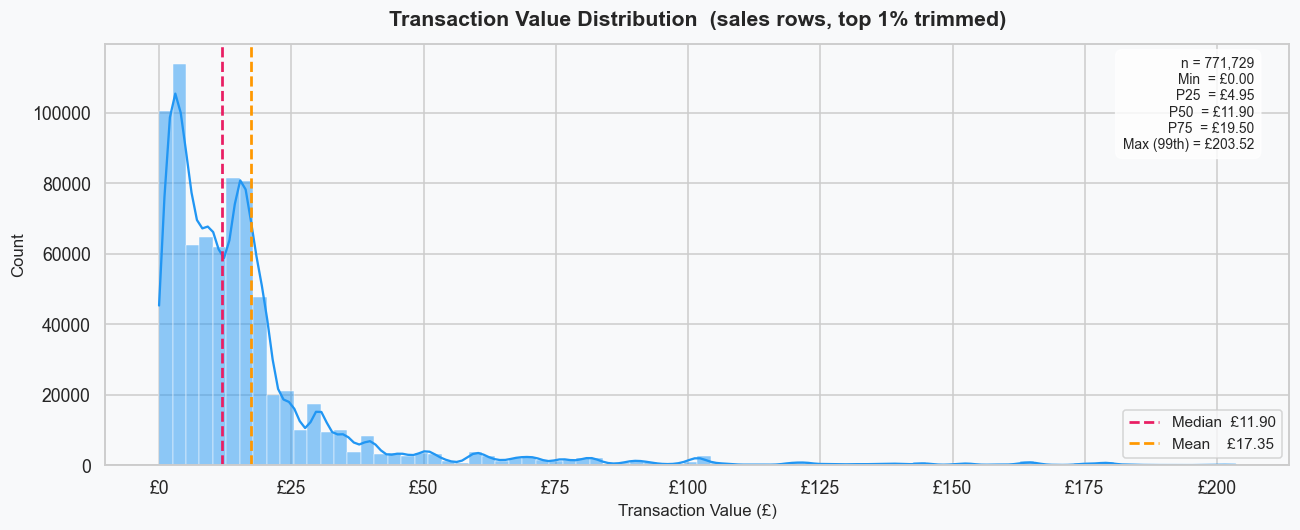

⚠  Full max (incl. outliers): £168,469.60
   Trimmed at 99th pct      : £203.52  (7766 rows excluded)


In [23]:
# ── 3.1 Transaction Value Distribution ──────────────────────────────────────
q99 = df_sales['TotalValue'].quantile(0.99)
data_plot = df_sales.loc[df_sales['TotalValue'] <= q99, 'TotalValue']

fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(data_plot, bins=80, kde=True, ax=ax, color=ACCENT,
             edgecolor='white', linewidth=0.3)

# Annotation: median & mean lines
median_val = data_plot.median()
mean_val   = data_plot.mean()
ax.axvline(median_val, color='#E91E63', linestyle='--', linewidth=1.8, label=f'Median  £{median_val:,.2f}')
ax.axvline(mean_val,   color='#FF9800', linestyle='--', linewidth=1.8, label=f'Mean    £{mean_val:,.2f}')

ax.set_title('Transaction Value Distribution  (sales rows, top 1% trimmed)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Transaction Value (£)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(fontsize=10)

# Stats box
stats_text = (
    f"n = {len(data_plot):,}\n"
    f"Min  = £{data_plot.min():,.2f}\n"
    f"P25  = £{data_plot.quantile(0.25):,.2f}\n"
    f"P50  = £{median_val:,.2f}\n"
    f"P75  = £{data_plot.quantile(0.75):,.2f}\n"
    f"Max (99th) = £{q99:,.2f}"
)
ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"⚠  Full max (incl. outliers): £{df_sales['TotalValue'].max():,.2f}")
print(f"   Trimmed at 99th pct      : £{q99:,.2f}  ({(df_sales['TotalValue'] > q99).sum()} rows excluded)")


### 3.2 Phân phối Số lượng mỗi dòng (Quantity per Line)
`Quantity` là số đơn vị trong một dòng hóa đơn. Phần lớn là đơn lẻ vài chục đơn vị, nhưng có một số đơn B2B hàng trăm đơn vị — cần trim để thấy rõ bulk của dữ liệu.


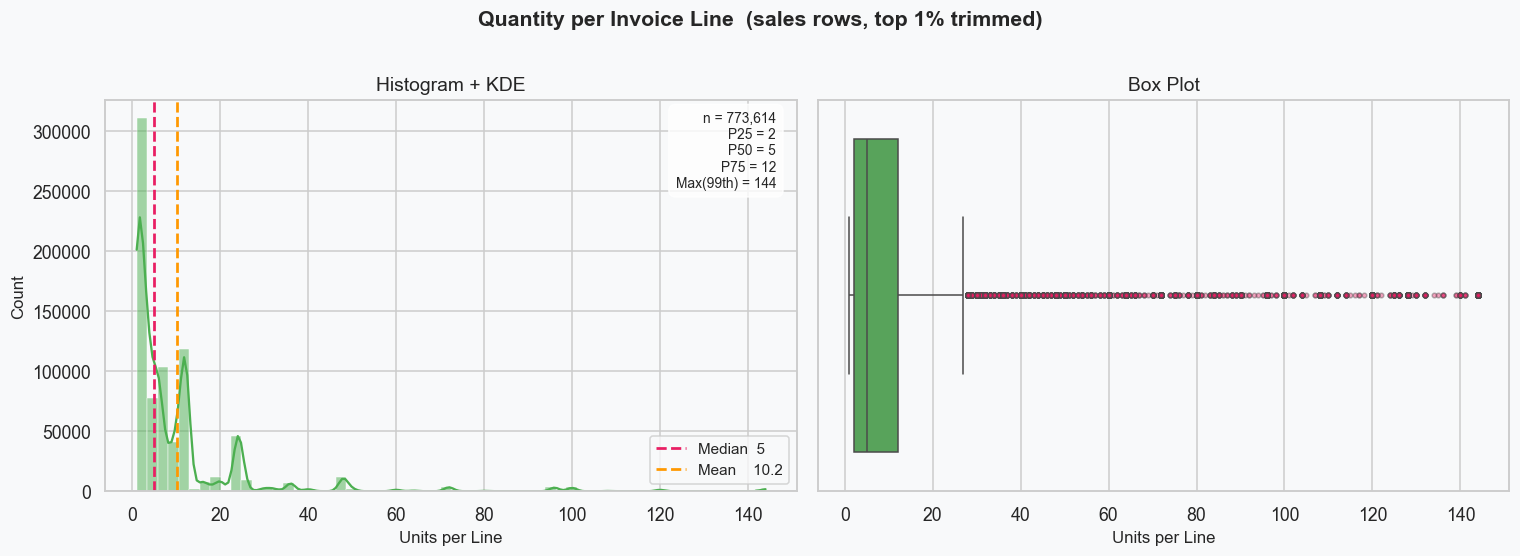

⚠  Full max (incl. outliers): 80,995 units
   Trimmed at 99th pct      : 144  (5881 rows excluded)


In [24]:
# ── 3.2 Quantity per Line Distribution ──────────────────────────────────────
q99q = df_sales['Quantity'].quantile(0.99)
data_qty = df_sales.loc[df_sales['Quantity'] <= q99q, 'Quantity']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Quantity per Invoice Line  (sales rows, top 1% trimmed)',
             fontsize=14, fontweight='bold', y=1.01)

# Left: histogram + KDE
sns.histplot(data_qty, bins=60, kde=True, ax=axes[0], color='#4CAF50',
             edgecolor='white', linewidth=0.3)
median_qty = data_qty.median()
mean_qty   = data_qty.mean()
axes[0].axvline(median_qty, color='#E91E63', linestyle='--', linewidth=1.8,
                label=f'Median  {median_qty:.0f}')
axes[0].axvline(mean_qty,   color='#FF9800', linestyle='--', linewidth=1.8,
                label=f'Mean    {mean_qty:.1f}')
axes[0].set_xlabel('Units per Line', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Histogram + KDE')
axes[0].legend(fontsize=10)

# Right: box plot to show spread & outliers within 99th pct
sns.boxplot(x=data_qty, ax=axes[1], color='#4CAF50',
            flierprops=dict(marker='o', markerfacecolor='#E91E63',
                            markersize=3, alpha=0.4))
axes[1].set_xlabel('Units per Line', fontsize=11)
axes[1].set_title('Box Plot')

# Stats annotation
stats_text = (
    f"n = {len(data_qty):,}\n"
    f"P25 = {data_qty.quantile(0.25):.0f}\n"
    f"P50 = {median_qty:.0f}\n"
    f"P75 = {data_qty.quantile(0.75):.0f}\n"
    f"Max(99th) = {q99q:.0f}"
)
axes[0].text(0.97, 0.97, stats_text, transform=axes[0].transAxes,
             fontsize=9, va='top', ha='right',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"⚠  Full max (incl. outliers): {df_sales['Quantity'].max():,} units")
print(f"   Trimmed at 99th pct      : {q99q:.0f}  ({(df_sales['Quantity'] > q99q).sum()} rows excluded)")


### 3.3 Phân phối Đơn giá (Unit Price)
`Price` là giá đơn vị sản phẩm (£). Lệch phải rõ rệt — đa số sản phẩm dưới £10, nhưng có một số mặt hàng cao cấp hoặc quà tặng tập thể có giá rất cao. Trim top 1% để lộ rõ phần thân.


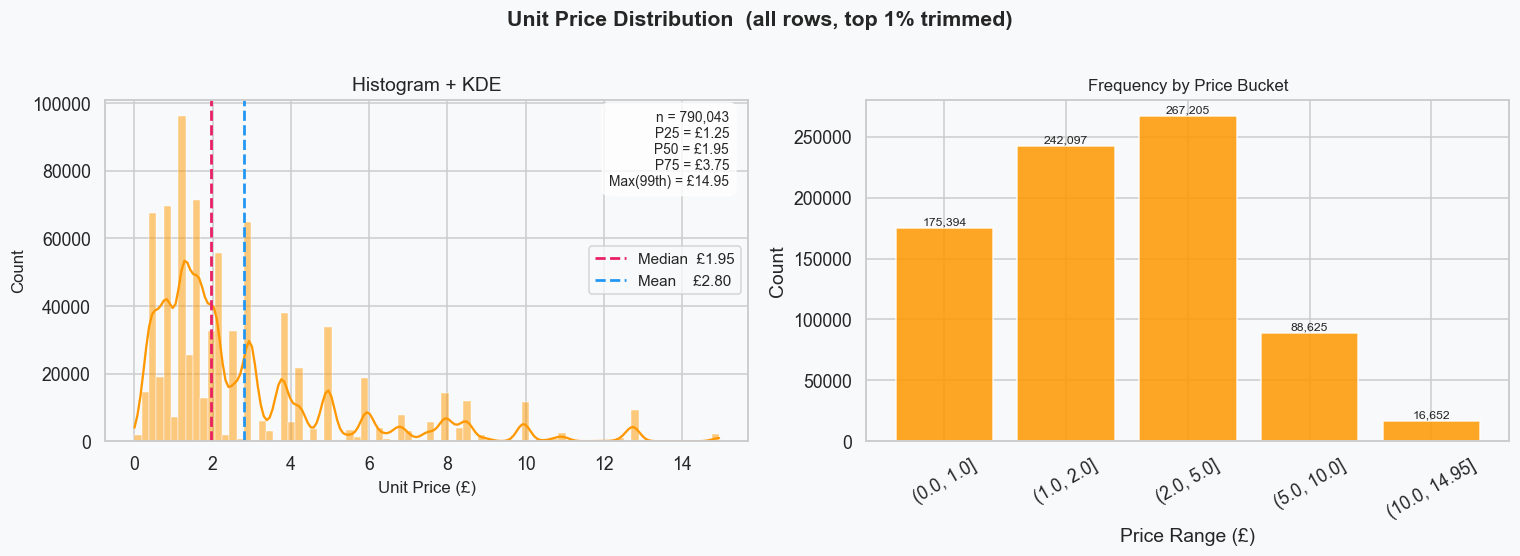

⚠  Full max (incl. outliers): £38,970.00
   Trimmed at 99th pct      : £14.95  (7842 rows excluded)


In [25]:
# ── 3.3 Unit Price Distribution ─────────────────────────────────────────────
q99p = df['Price'].quantile(0.99)
data_price = df.loc[df['Price'] <= q99p, 'Price']

# Price buckets — only keep breakpoints strictly below q99p, then append q99p
raw_breaks = [0, 1, 2, 5, 10, 20, 50]
bin_edges  = [b for b in raw_breaks if b < q99p] + [q99p]

bucket_counts = pd.cut(data_price, bins=bin_edges).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Unit Price Distribution  (all rows, top 1% trimmed)',
             fontsize=14, fontweight='bold', y=1.01)

# Left: histogram + KDE
sns.histplot(data_price, bins=80, kde=True, ax=axes[0], color='#FF9800',
             edgecolor='white', linewidth=0.3)
median_p = data_price.median()
mean_p   = data_price.mean()
axes[0].axvline(median_p, color='#E91E63', linestyle='--', linewidth=1.8,
                label=f'Median  £{median_p:.2f}')
axes[0].axvline(mean_p,   color='#2196F3', linestyle='--', linewidth=1.8,
                label=f'Mean    £{mean_p:.2f}')
axes[0].set_xlabel('Unit Price (£)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Histogram + KDE')
axes[0].legend(fontsize=10)

stats_text = (
    f"n = {len(data_price):,}\n"
    f"P25 = £{data_price.quantile(0.25):.2f}\n"
    f"P50 = £{median_p:.2f}\n"
    f"P75 = £{data_price.quantile(0.75):.2f}\n"
    f"Max(99th) = £{q99p:.2f}"
)
axes[0].text(0.97, 0.97, stats_text, transform=axes[0].transAxes,
             fontsize=9, va='top', ha='right',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

# Right: price bucket bar chart
bucket_labels = [str(b) for b in bucket_counts.index]
axes[1].bar(bucket_labels, bucket_counts.values,
            color='#FF9800', alpha=0.85, edgecolor='white')
axes[1].set_title('Frequency by Price Bucket', fontsize=11)
axes[1].set_xlabel('Price Range (£)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(bucket_counts.values):
    axes[1].text(i, v + max(bucket_counts.values) * 0.01,
                 f'{v:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"⚠  Full max (incl. outliers): £{df['Price'].max():,.2f}")
print(f"   Trimmed at 99th pct      : £{q99p:.2f}  ({(df['Price'] > q99p).sum()} rows excluded)")


### 3.4 Tỷ lệ Bán hàng vs Hàng trả (Sales vs Returns)
So sánh số dòng giao dịch bán ra và hàng bị trả lại, kết hợp với giá trị tiền tương ứng. Tỷ lệ hoàn trả cao có thể ảnh hưởng đáng kể đến doanh thu thuần.


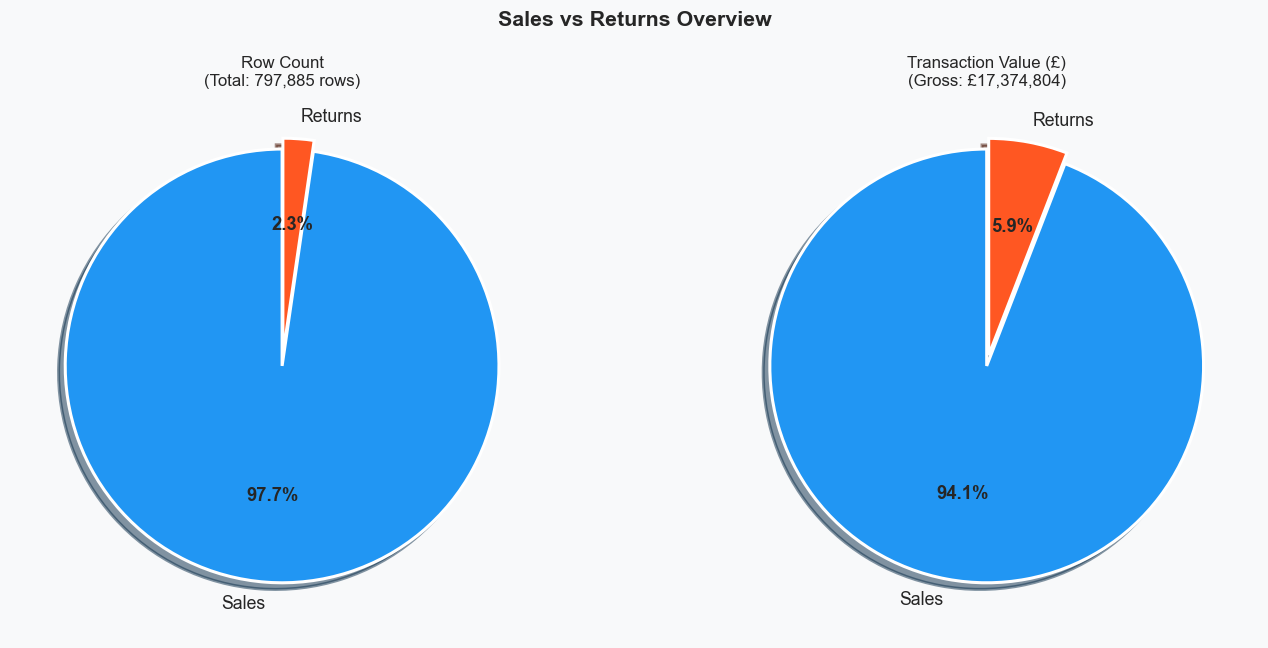

      Metric                              Sales         Returns   Return %
───────────────────────────────────────────────────────────────────────────
      Row Count                         779,495          18,390       2.3%
      Gross Value (£)             17,374,804.27    1,084,812.98       6.2%
      Net Revenue (£)             16,289,991.29


In [26]:
# ── 3.4 Sales vs Returns ────────────────────────────────────────────────────
n_sales   = len(df_sales)
n_returns = len(df_returns)
v_sales   = df_sales['TotalValue'].sum()
v_returns = abs(df_returns['TotalValue'].sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Sales vs Returns Overview', fontsize=14, fontweight='bold')

COLORS = [ACCENT, ACCENT2]

# Left: row count pie
wedges, texts, autotexts = axes[0].pie(
    [n_sales, n_returns],
    labels=['Sales', 'Returns'],
    autopct='%1.1f%%',
    colors=COLORS,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    explode=(0, 0.05),
    shadow=True,
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[0].set_title(f'Row Count\n(Total: {n_sales + n_returns:,} rows)', fontsize=11)

# Right: value pie
wedges2, texts2, autotexts2 = axes[1].pie(
    [v_sales, v_returns],
    labels=['Sales', 'Returns'],
    autopct='%1.1f%%',
    colors=COLORS,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    explode=(0, 0.05),
    shadow=True,
)
for at in autotexts2:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title(f'Transaction Value (£)\n(Gross: £{v_sales:,.0f})', fontsize=11)

plt.tight_layout()
plt.show()

print(f"{'':5} {'Metric':<25} {'Sales':>15} {'Returns':>15} {'Return %':>10}")
print('─' * 75)
print(f"{'':5} {'Row Count':<25} {n_sales:>15,} {n_returns:>15,} {n_returns/(n_sales+n_returns)*100:>9.1f}%")
print(f"{'':5} {'Gross Value (£)':<25} {v_sales:>15,.2f} {v_returns:>15,.2f} {v_returns/v_sales*100:>9.1f}%")
print(f"{'':5} {'Net Revenue (£)':<25} {v_sales - v_returns:>15,.2f}")


### 3.5 Phân phối Loại Hóa đơn (Invoice Type)
Phân loại hóa đơn theo `InvoiceType` — giúp xác định cấu trúc giao dịch: bán hàng thông thường, hoàn trả, hay các loại đặc biệt khác.


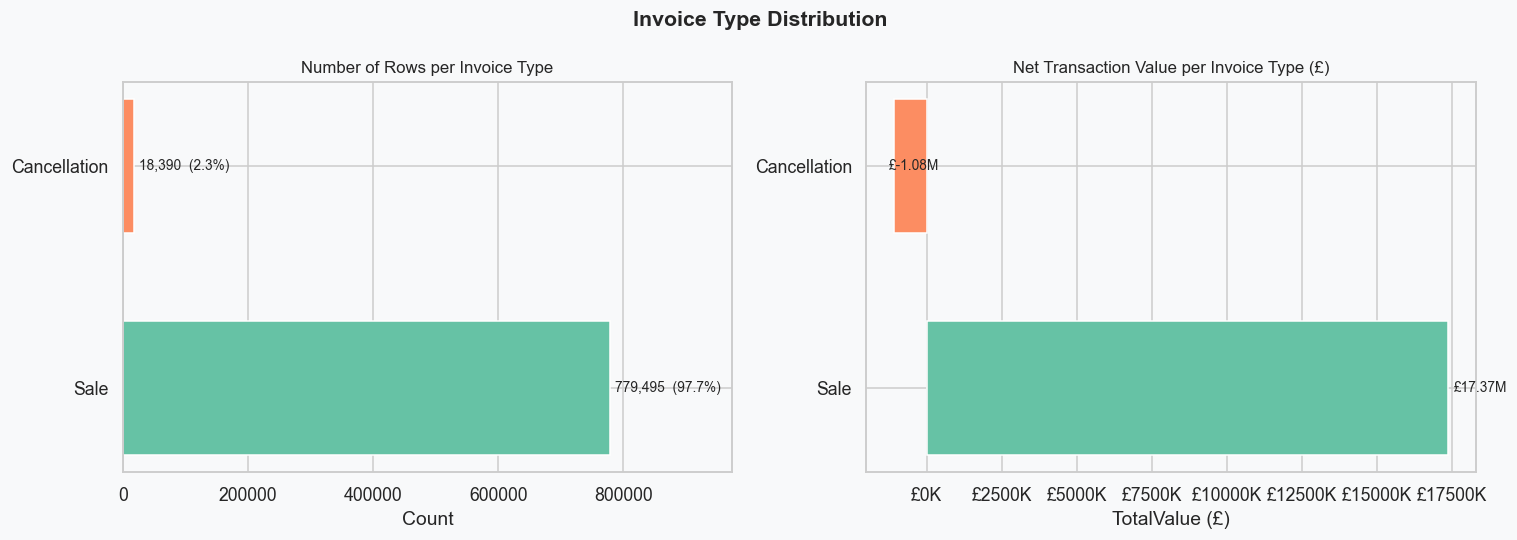


Invoice Type Summary:


,Count,Count %,Revenue (£)
InvoiceType,,,
Sale,"779,495",97.70%,"£17,374,804.27"
Cancellation,"18,390",2.30%,"£-1,084,812.98"


In [27]:
# ── 3.5 Invoice Type Distribution ───────────────────────────────────────────
inv_counts = df['InvoiceType'].value_counts()
inv_pct    = inv_counts / inv_counts.sum() * 100

# Revenue per invoice type
inv_revenue = df.groupby('InvoiceType')['TotalValue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Invoice Type Distribution', fontsize=14, fontweight='bold')

palette = sns.color_palette('Set2', n_colors=len(inv_counts))

# Left: count bar chart
bars = axes[0].barh(inv_counts.index, inv_counts.values,
                    color=palette, edgecolor='white', height=0.6)
axes[0].set_title('Number of Rows per Invoice Type', fontsize=11)
axes[0].set_xlabel('Count')
# Add count + % labels
for bar, cnt, pct in zip(bars, inv_counts.values, inv_pct.values):
    axes[0].text(cnt + inv_counts.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{cnt:,}  ({pct:.1f}%)', va='center', fontsize=9)
axes[0].set_xlim(0, inv_counts.max() * 1.25)

# Right: revenue bar chart
inv_rev_plot = inv_revenue.reindex(inv_counts.index)
bars2 = axes[1].barh(inv_rev_plot.index, inv_rev_plot.values.astype(float),
                     color=palette, edgecolor='white', height=0.6)
axes[1].set_title('Net Transaction Value per Invoice Type (£)', fontsize=11)
axes[1].set_xlabel('TotalValue (£)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
for bar, val in zip(bars2, inv_rev_plot.values):
    label = f'£{val:,.0f}' if abs(val) < 1e6 else f'£{val/1e6:.2f}M'
    axes[1].text(val + (inv_rev_plot.abs().max() * 0.01 * (1 if val >= 0 else -1)),
                 bar.get_y() + bar.get_height() / 2,
                 label, va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\nInvoice Type Summary:')
summary = pd.DataFrame({
    'Count'   : inv_counts,
    'Count %' : inv_pct.round(2),
    'Revenue (£)': inv_revenue,
}).sort_values('Count', ascending=False)
display(summary.style.format({'Count': '{:,}', 'Count %': '{:.2f}%',
                               'Revenue (£)': '£{:,.2f}'}))


---
## 4. Phân tích doanh thu theo thời gian (Time Series Analysis)

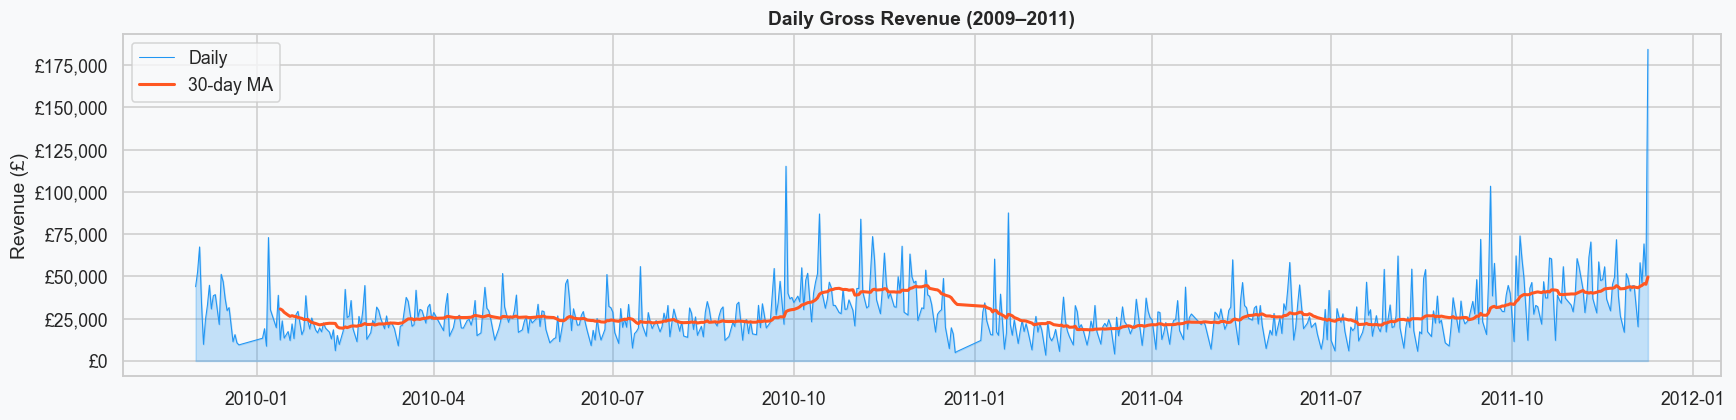

In [28]:
# ── 4.1 Daily revenue ────────────────────────────────────────────────────────
daily = (
    df_sales
    .groupby(df_sales['InvoiceDate'].dt.date)['TotalValue']
    .sum()
    .reset_index()
    .rename(columns={'InvoiceDate': 'Date', 'TotalValue': 'Revenue'})
)
daily['Date'] = pd.to_datetime(daily['Date'])
daily['MA30']  = daily['Revenue'].rolling(30).mean()

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(daily['Date'], daily['Revenue'], alpha=0.25, color=ACCENT)
ax.plot(daily['Date'], daily['Revenue'], linewidth=0.7, color=ACCENT, label='Daily')
ax.plot(daily['Date'], daily['MA30'], linewidth=2, color=ACCENT2, label='30-day MA')
ax.set_title('Daily Gross Revenue (2009–2011)', fontweight='bold')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

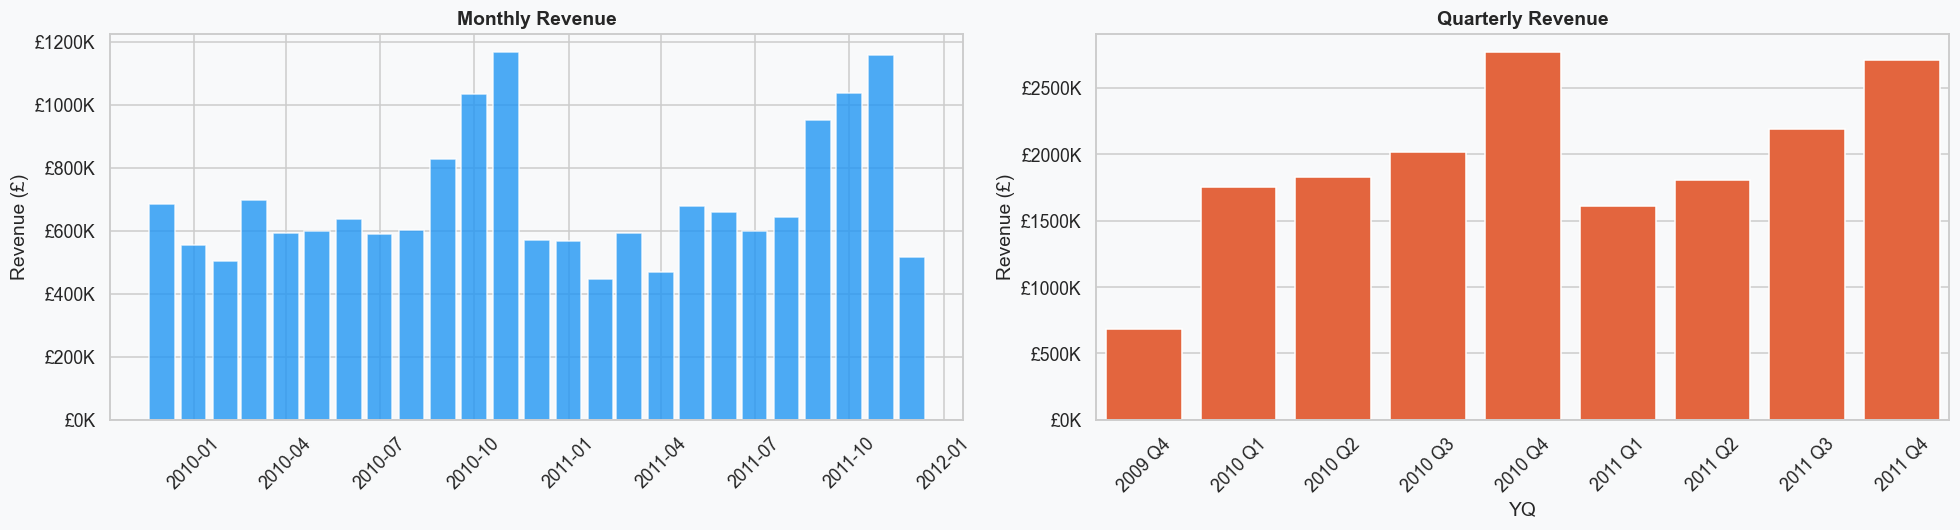

In [29]:
# ── 4.2 Monthly & Quarterly breakdown ────────────────────────────────────────
monthly = (
    df_sales.groupby(['Year', 'Month'])['TotalValue']
    .sum().reset_index()
)
monthly['Date'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))

quarterly = (
    df_sales.groupby(['Year', 'Quarter'])['TotalValue']
    .sum().reset_index()
)
quarterly['YQ'] = quarterly['Year'].astype(str) + ' Q' + quarterly['Quarter'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(monthly['Date'], monthly['TotalValue'], width=25, color=ACCENT, alpha=0.8)
axes[0].set_title('Monthly Revenue', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=quarterly, x='YQ', y='TotalValue', ax=axes[1], color=ACCENT2)
axes[1].set_title('Quarterly Revenue', fontweight='bold')
axes[1].set_ylabel('Revenue (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

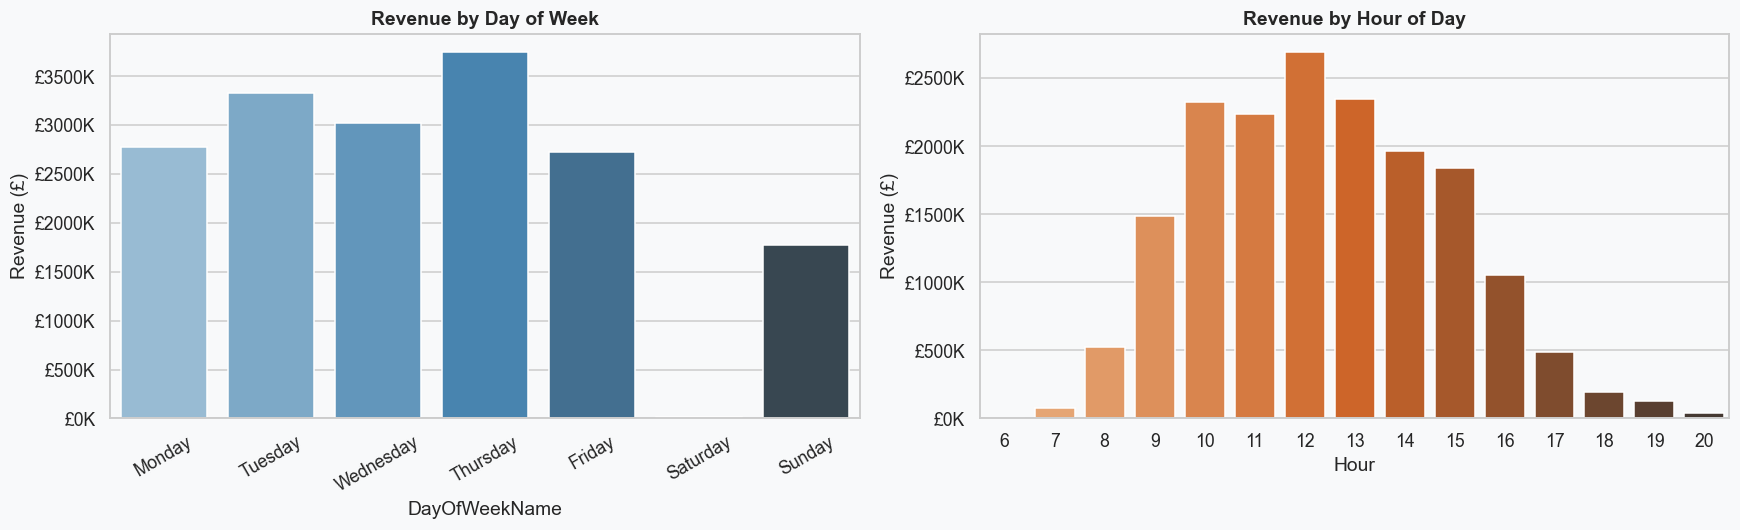

In [30]:
# ── 4.3 Day-of-week & Hour patterns ──────────────────────────────────────────
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev   = df_sales.groupby('DayOfWeekName')['TotalValue'].sum().reindex(dow_order)
hour_rev  = df_sales.groupby('Hour')['TotalValue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=dow_rev.index, y=dow_rev.values, ax=axes[0], palette='Blues_d')
axes[0].set_title('Revenue by Day of Week', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(x=hour_rev.index, y=hour_rev.values, ax=axes[1], palette='Oranges_d')
axes[1].set_title('Revenue by Hour of Day', fontweight='bold')
axes[1].set_ylabel('Revenue (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

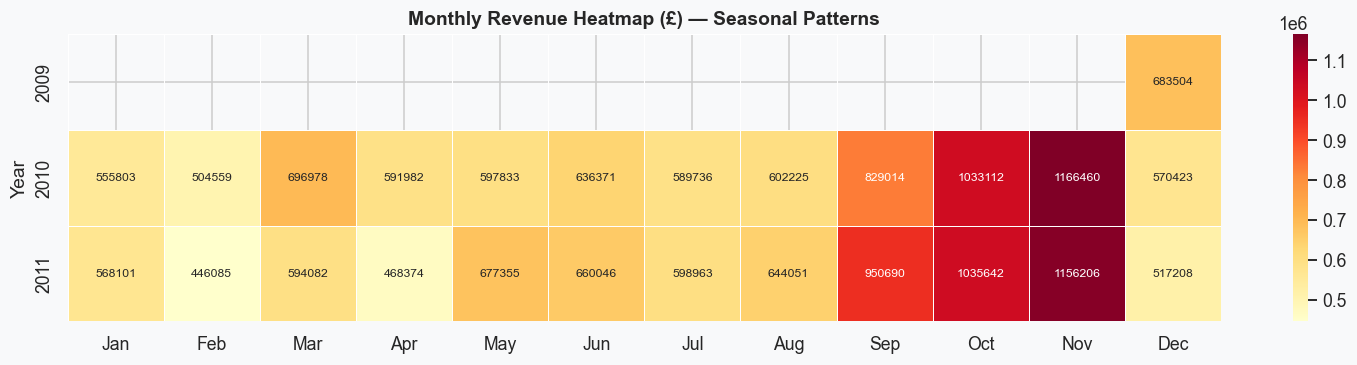

In [31]:
# ── 4.4 Monthly seasonality heatmap (Year × Month) ───────────────────────────
pivot_month = (
    df_sales.groupby(['Year', 'Month'])['TotalValue']
    .sum()
    .unstack('Month')
)
pivot_month.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 3.5))
sns.heatmap(
    pivot_month, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Monthly Revenue Heatmap (£) — Seasonal Patterns', fontweight='bold')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

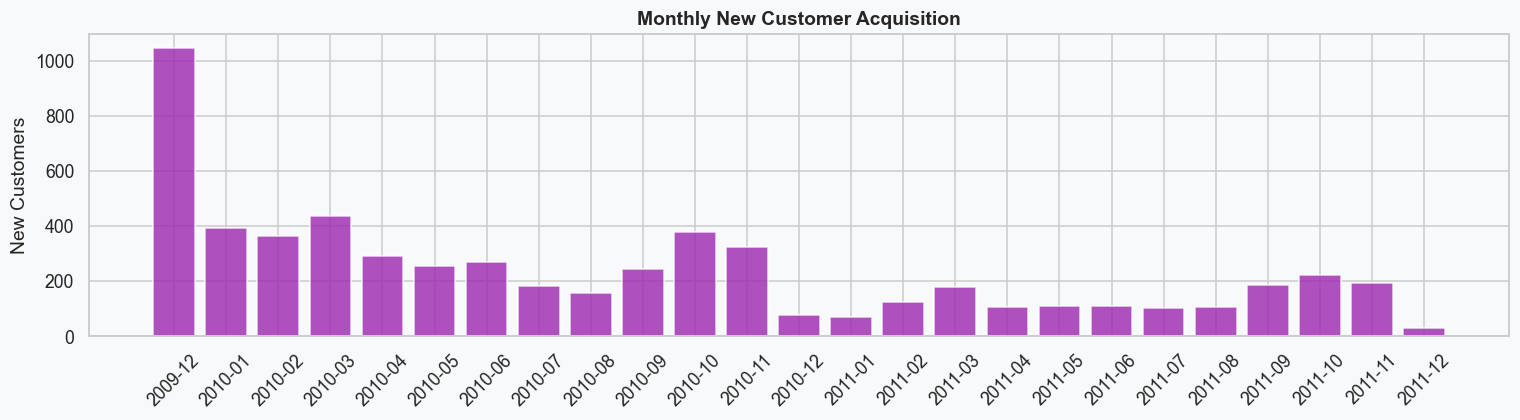

In [32]:
# ── 4.5 New customer acquisition over time ───────────────────────────────────
new_cust = (
    df.groupby(df['FirstPurchaseDate'].dt.to_period('M'))['Customer ID']
    .nunique()
    .reset_index()
    .rename(columns={'FirstPurchaseDate': 'Month', 'Customer ID': 'NewCustomers'})
)
new_cust['Month'] = new_cust['Month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(new_cust['Month'], new_cust['NewCustomers'], color='#9C27B0', alpha=0.8)
ax.set_title('Monthly New Customer Acquisition', fontweight='bold')
ax.set_ylabel('New Customers')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## 5. Phân tích khách hàng & RFM

In [33]:
# ── 5.1 Build RFM table ──────────────────────────────────────────────────────
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = (
    df_sales.groupby('Customer ID')
    .agg(
        Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
        Frequency = ('Invoice',     'nunique'),
        Monetary  = ('TotalValue',  'sum'),
    )
    .reset_index()
)

# RFM quintile scoring (1=worst, 5=best)
rfm['R'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M'] = pd.qcut(rfm['Monetary'],  5, labels=[1,2,3,4,5])
rfm['RFM_Score'] = rfm['R'].astype(int) + rfm['F'].astype(int) + rfm['M'].astype(int)

def rfm_segment(row):
    r, f, m = int(row['R']), int(row['F']), int(row['M'])
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Churned'
    else:
        return 'Potential'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

print('RFM Summary:')
display(rfm[['Recency','Frequency','Monetary','RFM_Score']].describe().T)
print('\nSegment Distribution:')
print(rfm['Segment'].value_counts().to_string())

RFM Summary:


,count,mean,std,min,25%,50%,75%,max
Recency,"5,881.00",201.46,209.47,1.00,26.00,96.00,380.00,739.00
Frequency,"5,881.00",6.29,13.01,1.00,1.00,3.00,7.00,398.00
Monetary,"5,881.00","2,954.40","14,437.32",0.00,341.90,865.60,"2,247.72","580,987.04"
RFM_Score,"5,881.00",9.01,3.64,3.00,6.00,9.00,12.00,15.00



Segment Distribution:
Segment
Churned          1525
Champions        1482
Loyal            1222
At Risk           824
New Customers     444
Potential         384


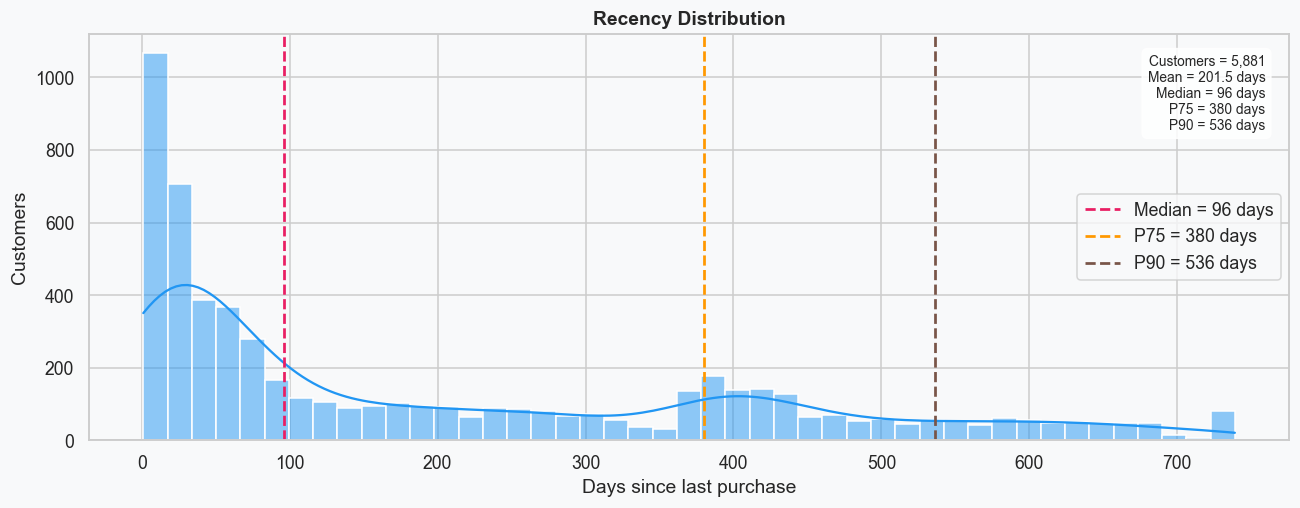

In [34]:
# ── 5.2 Recency distribution ──────────────────────────────────────────────────
median_recency = rfm['Recency'].median()
p75_recency = rfm['Recency'].quantile(0.75)
p90_recency = rfm['Recency'].quantile(0.90)

fig, ax = plt.subplots(figsize=(12, 4.8))
sns.histplot(rfm['Recency'], bins=45, kde=True, ax=ax, color=ACCENT)
ax.axvline(median_recency, color='#E91E63', linestyle='--', linewidth=1.8, label=f'Median = {median_recency:,.0f} days')
ax.axvline(p75_recency, color='#FF9800', linestyle='--', linewidth=1.8, label=f'P75 = {p75_recency:,.0f} days')
ax.axvline(p90_recency, color='#795548', linestyle='--', linewidth=1.8, label=f'P90 = {p90_recency:,.0f} days')
ax.set_title('Recency Distribution', fontweight='bold')
ax.set_xlabel('Days since last purchase')
ax.set_ylabel('Customers')
ax.legend()

stats_text = (
    f"Customers = {len(rfm):,}\n"
    f"Mean = {rfm['Recency'].mean():,.1f} days\n"
    f"Median = {median_recency:,.0f} days\n"
    f"P75 = {p75_recency:,.0f} days\n"
    f"P90 = {p90_recency:,.0f} days"
)
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes,
        ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.show()

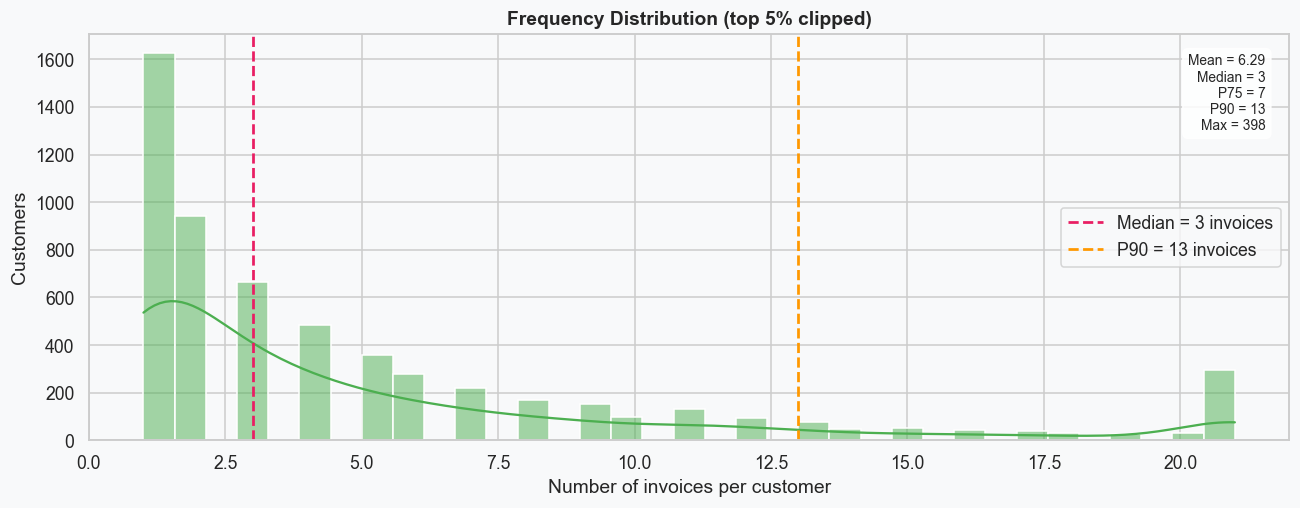

In [35]:
# ── 5.3 Frequency distribution ────────────────────────────────────────────────
freq_cap = rfm['Frequency'].quantile(0.95)
freq_plot = rfm['Frequency'].clip(upper=freq_cap)
median_freq = rfm['Frequency'].median()
p90_freq = rfm['Frequency'].quantile(0.90)

fig, ax = plt.subplots(figsize=(12, 4.8))
sns.histplot(freq_plot, bins=35, kde=True, ax=ax, color='#4CAF50')
ax.axvline(median_freq, color='#E91E63', linestyle='--', linewidth=1.8, label=f'Median = {median_freq:,.0f} invoices')
ax.axvline(p90_freq, color='#FF9800', linestyle='--', linewidth=1.8, label=f'P90 = {p90_freq:,.0f} invoices')
ax.set_title('Frequency Distribution (top 5% clipped)', fontweight='bold')
ax.set_xlabel('Number of invoices per customer')
ax.set_ylabel('Customers')
ax.legend()

stats_text = (
    f"Mean = {rfm['Frequency'].mean():,.2f}\n"
    f"Median = {median_freq:,.0f}\n"
    f"P75 = {rfm['Frequency'].quantile(0.75):,.0f}\n"
    f"P90 = {p90_freq:,.0f}\n"
    f"Max = {rfm['Frequency'].max():,.0f}"
)
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes,
        ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.show()

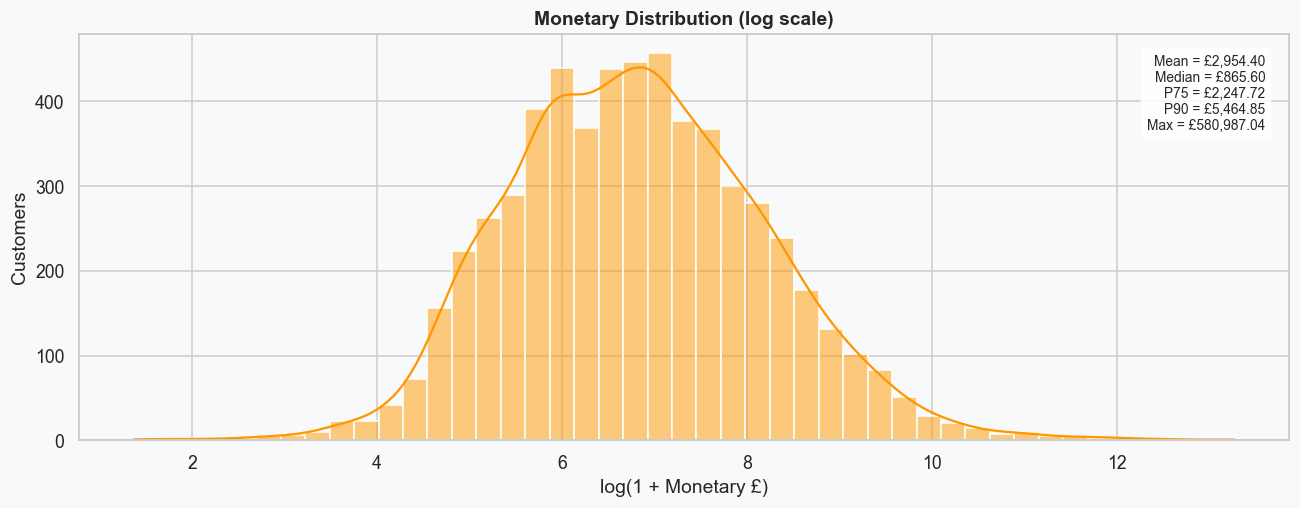

In [36]:
# ── 5.4 Monetary distribution ────────────────────────────────────────────────
pos_monetary = rfm.loc[rfm['Monetary'] > 0, 'Monetary']
log_monetary = np.log1p(pos_monetary)

fig, ax = plt.subplots(figsize=(12, 4.8))
sns.histplot(log_monetary, bins=45, kde=True, ax=ax, color='#FF9800')
ax.set_title('Monetary Distribution (log scale)', fontweight='bold')
ax.set_xlabel('log(1 + Monetary £)')
ax.set_ylabel('Customers')

stats_text = (
    f"Mean = £{rfm['Monetary'].mean():,.2f}\n"
    f"Median = £{rfm['Monetary'].median():,.2f}\n"
    f"P75 = £{rfm['Monetary'].quantile(0.75):,.2f}\n"
    f"P90 = £{rfm['Monetary'].quantile(0.90):,.2f}\n"
    f"Max = £{rfm['Monetary'].max():,.2f}"
)
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes,
        ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.show()

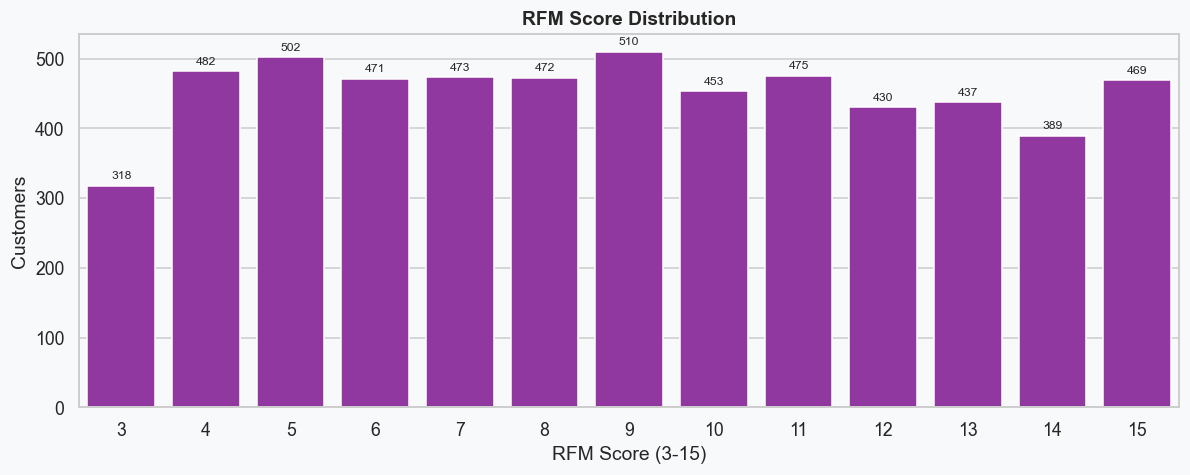

In [37]:
# ── 5.5 RFM score distribution ────────────────────────────────────────────────
score_counts = rfm['RFM_Score'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(x=score_counts.index, y=score_counts.values, ax=ax, color='#9C27B0')
ax.set_title('RFM Score Distribution', fontweight='bold')
ax.set_xlabel('RFM Score (3-15)')
ax.set_ylabel('Customers')

for index, value in enumerate(score_counts.values):
    ax.text(index, value + 10, f'{value:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

#### Nhận xét chi tiết từ các phân phối RFM

- `Recency` lệch phải mạnh: median chỉ `96` ngày nhưng `P75 = 380` ngày và `P90 = 536` ngày. Nghĩa là một phần tư tệp khách hàng đã im lặng hơn một năm, khá đáng chú ý cho bài toán churn.
- `Frequency` tập trung ở mức thấp: median `3` hóa đơn, `75%` khách hàng chỉ có tối đa `7` hóa đơn. Tuy nhiên đuôi kéo dài tới `398` hóa đơn cho thấy có một nhóm mua rất thường xuyên đang kéo mean lên `6.29`.
- `Monetary` cực lệch phải: median chỉ `£865.60` nhưng mean lên tới `£2,954.40`, còn giá trị lớn nhất đạt `£580,987.04`. Điều này cho thấy doanh thu bị chi phối bởi một số ít khách hàng rất lớn.
- Phân phối `RFM_Score` khá đều, nhưng nhóm điểm cao `13-15` có `1,295` khách hàng, gần tương đương nhóm điểm thấp `3-5` với `1,302` khách hàng. Tệp khách hàng đang tách thành hai cực rõ rệt: rất tốt và khá yếu.

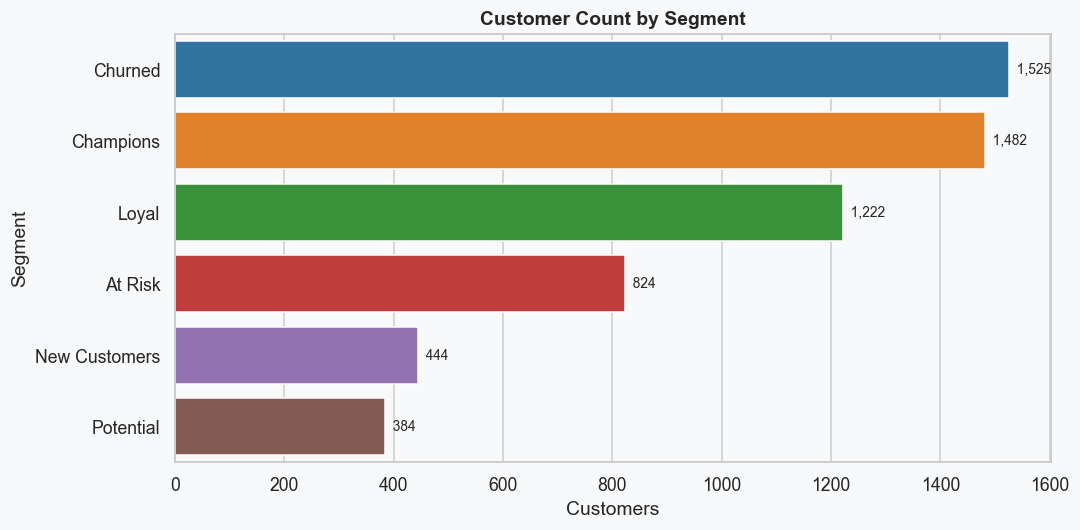

In [38]:
# ── 5.6 Customer count by segment ─────────────────────────────────────────────
seg_counts = rfm['Segment'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=seg_counts.values, y=seg_counts.index, ax=ax, palette='tab10')
ax.set_title('Customer Count by Segment', fontweight='bold')
ax.set_xlabel('Customers')
ax.set_ylabel('Segment')

for index, value in enumerate(seg_counts.values):
    ax.text(value, index, f'  {value:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

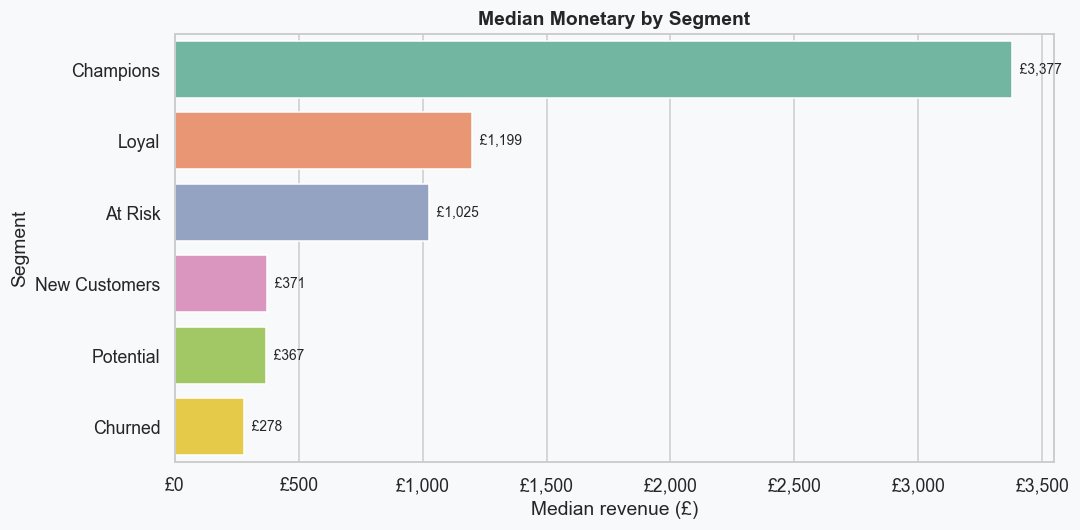

In [39]:
# ── 5.7 Median monetary by segment ────────────────────────────────────────────
seg_monetary = rfm.groupby('Segment')['Monetary'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=seg_monetary.values, y=seg_monetary.index, ax=ax, palette='Set2')
ax.set_title('Median Monetary by Segment', fontweight='bold')
ax.set_xlabel('Median revenue (£)')
ax.set_ylabel('Segment')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

for index, value in enumerate(seg_monetary.values):
    ax.text(value, index, f'  £{value:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

#### Nhận xét chi tiết theo segment

- Cơ cấu khách hàng đang bị phân cực: `Churned` chiếm `25.93%`, gần tương đương `Champions` ở mức `25.20%`. Doanh nghiệp vừa có một lõi khách hàng rất tốt, vừa có một cụm rời bỏ rất lớn.
- Dù chỉ chiếm khoảng một phần tư khách hàng, `Champions` đóng góp tới `69.21%` tổng doanh thu khách hàng và có median monetary `£3,376.76`. Đây là nhóm cần ưu tiên giữ chân và khai thác cross-sell/up-sell.
- `At Risk` chiếm `14.01%` nhưng median monetary vẫn ở mức `£1,024.57`, cao hơn rõ so với `New Customers`, `Potential` và `Churned`. Đây là tệp có ROI can thiệp giữ chân tốt hơn nhiều so với win-back đại trà.
- `Churned` có quy mô lớn nhưng median monetary chỉ `£278.34`, nên chiến lược kéo lại nên chọn lọc theo lịch sử chi tiêu thay vì bắn lại toàn bộ tệp.

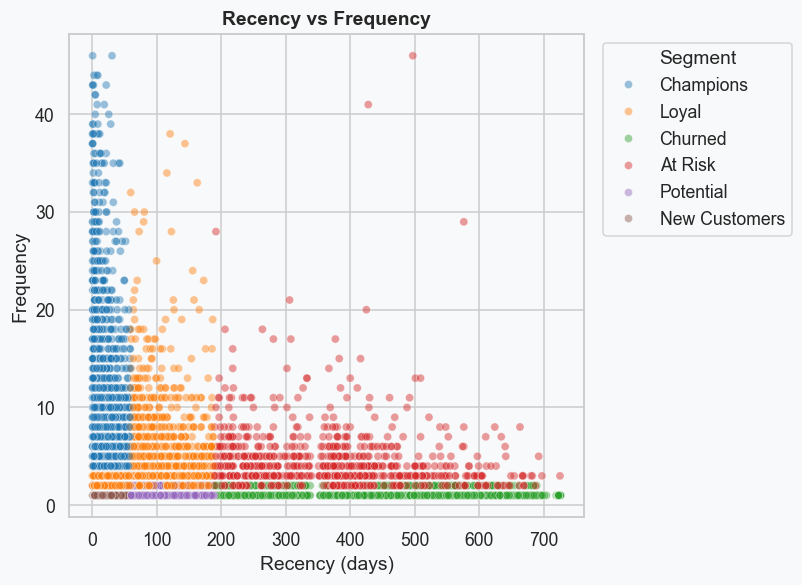

In [40]:
# ── 5.8 Recency vs Frequency scatter ──────────────────────────────────────────
r_cap = rfm['Recency'].quantile(0.99)
f_cap = rfm['Frequency'].quantile(0.99)
m_cap = rfm['Monetary'].quantile(0.99)
rfm_scatter_sample = rfm[
    (rfm['Recency'] <= r_cap)
    & (rfm['Frequency'] <= f_cap)
    & (rfm['Monetary'] <= m_cap)
].copy()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.scatterplot(
    data=rfm_scatter_sample,
    x='Recency',
    y='Frequency',
    hue='Segment',
    palette='tab10',
    alpha=0.45,
    s=28,
    ax=ax,
)
ax.set_title('Recency vs Frequency', fontweight='bold')
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency')
ax.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

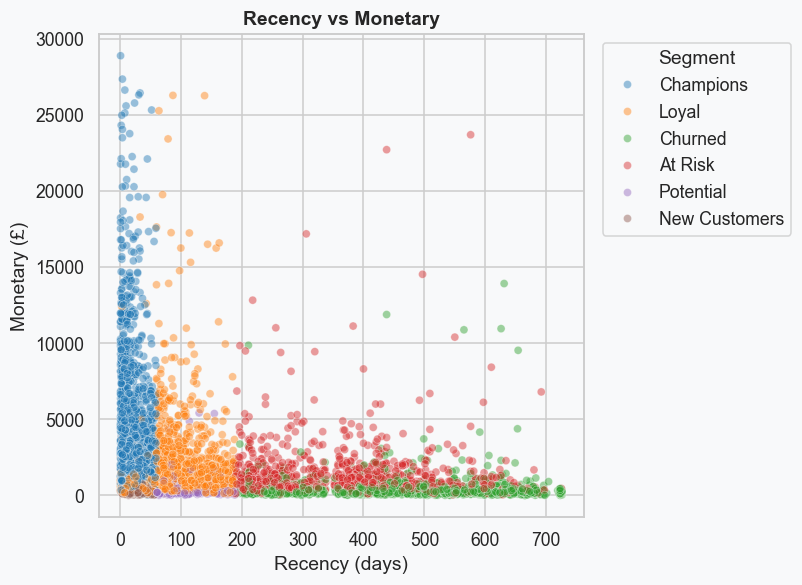

In [41]:
# ── 5.9 Recency vs Monetary scatter ───────────────────────────────────────────
if 'rfm_scatter_sample' not in globals():
    r_cap = rfm['Recency'].quantile(0.99)
    f_cap = rfm['Frequency'].quantile(0.99)
    m_cap = rfm['Monetary'].quantile(0.99)
    rfm_scatter_sample = rfm[
        (rfm['Recency'] <= r_cap)
        & (rfm['Frequency'] <= f_cap)
        & (rfm['Monetary'] <= m_cap)
    ].copy()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.scatterplot(
    data=rfm_scatter_sample,
    x='Recency',
    y='Monetary',
    hue='Segment',
    palette='tab10',
    alpha=0.45,
    s=28,
    ax=ax,
)
ax.set_title('Recency vs Monetary', fontweight='bold')
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Monetary (£)')
ax.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

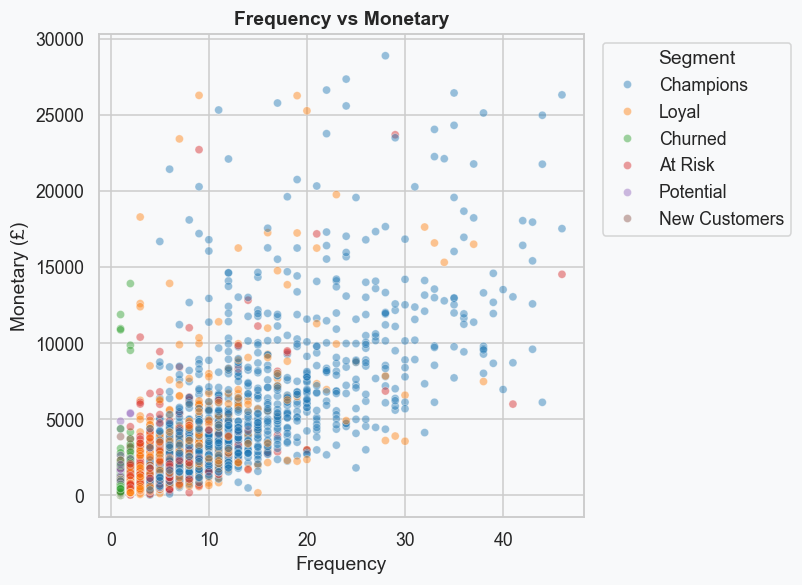

In [42]:
# ── 5.10 Frequency vs Monetary scatter ────────────────────────────────────────
r_cap = rfm['Recency'].quantile(0.99)
f_cap = rfm['Frequency'].quantile(0.99)
m_cap = rfm['Monetary'].quantile(0.99)
rfm_scatter_sample = rfm[
    (rfm['Recency'] <= r_cap)
    & (rfm['Frequency'] <= f_cap)
    & (rfm['Monetary'] <= m_cap)
].copy()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.scatterplot(
    data=rfm_scatter_sample,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    palette='tab10',
    alpha=0.45,
    s=28,
    ax=ax,
)
ax.set_title('Frequency vs Monetary', fontweight='bold')
ax.set_xlabel('Frequency')
ax.set_ylabel('Monetary (£)')
ax.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Nhận xét chi tiết từ các scatter plots

- `Frequency` và `Monetary` có tương quan dương khá rõ (`corr ≈ 0.628`), nên số lần mua lặp lại là tín hiệu mạnh nhất cho tổng giá trị khách hàng.
- `Recency` có tương quan âm với `Frequency` (`-0.257`) và `Monetary` (`-0.125`): khách hàng càng lâu chưa quay lại thì càng dễ trượt xuống nhóm giá trị thấp, nhưng recency một mình chưa đủ để ước lượng doanh thu.
- Cụm `Champions` tập trung ở vùng recency thấp, frequency cao, monetary cao; `Churned` nằm ở góc ngược lại. Điều này xác nhận logic segment đang phản ánh khá đúng hành vi mua hàng.
- Với bài toán dự báo rời bỏ, nên kết hợp `Recency` làm tín hiệu cảnh báo sớm và `Frequency` làm biến neo về giá trị, thay vì dựa vào một trục đơn lẻ.

---
## 6. Phân tích sản phẩm (Product Analysis)

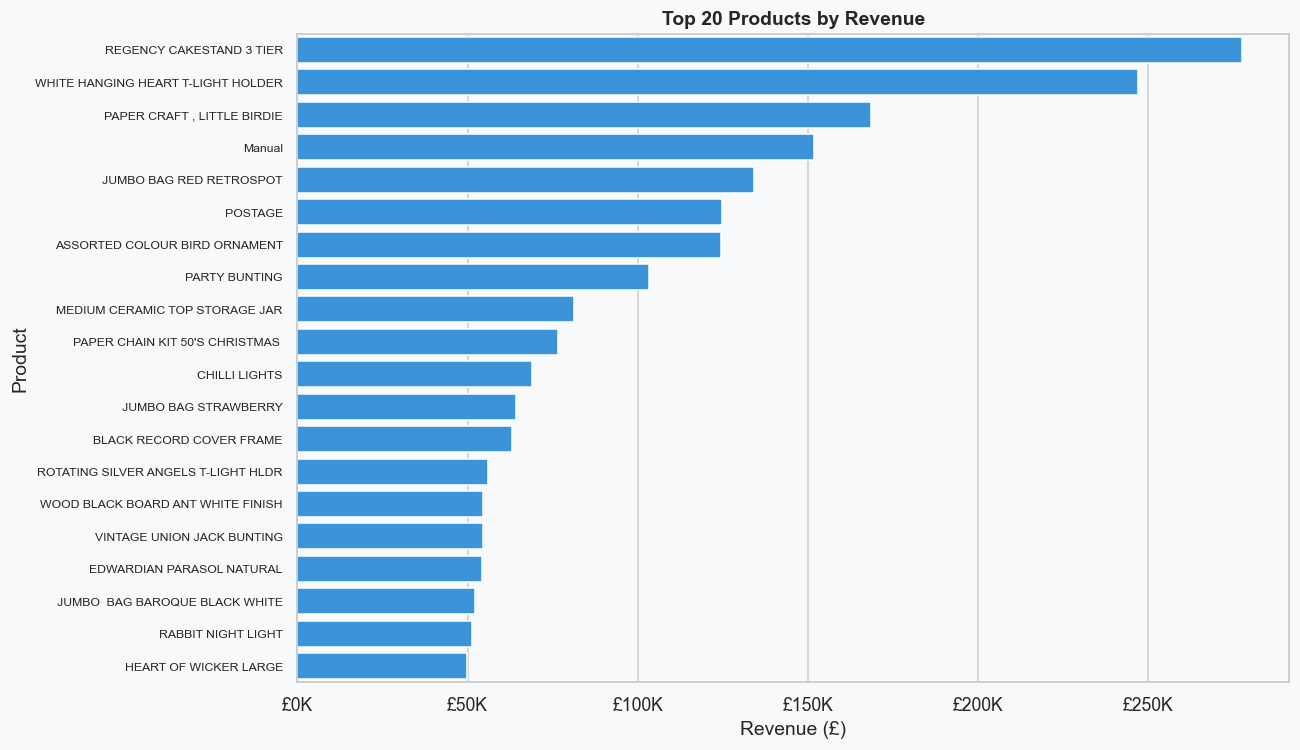


Top 10 Products by Revenue:


,Description,TotalRevenue,TotalQuantity,UniqueCustomers,AvgPrice
1862,REGENCY CAKESTAND 3 TIER,"277,656.25",24139,1314,12.45
4751,WHITE HANGING HEART T-LIGHT HOLDER,"247,048.01",91757,1490,2.87
3283,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,2.08
5309,Manual,"151,777.67",9391,443,212.60
4725,JUMBO BAG RED RETROSPOT,"134,307.44",74224,860,1.97
5311,POSTAGE,"124,648.04",5235,405,29.94
4456,ASSORTED COLOUR BIRD ORNAMENT,"124,351.86",78234,1010,1.68
3627,PARTY BUNTING,"103,283.38",23464,894,4.77
2781,MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73",77916,138,1.22
1449,PAPER CHAIN KIT 50'S CHRISTMAS,"76,598.18",28380,896,2.92


In [43]:
# ── 6.1 Top 20 products by revenue ────────────────────────────────────────────
product_stats = (
    df_sales.groupby(['StockCode', 'Description'])
    .agg(
        TotalRevenue=('TotalValue', 'sum'),
        TotalQuantity=('Quantity', 'sum'),
        UniqueCustomers=('Customer ID', 'nunique'),
        AvgPrice=('Price', 'mean'),
    )
    .reset_index()
    .sort_values('TotalRevenue', ascending=False)
)

top20_rev = product_stats.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=top20_rev, x='TotalRevenue', y='Description', ax=ax, color=ACCENT)
ax.set_title('Top 20 Products by Revenue', fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.set_ylabel('Product')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

print('\nTop 10 Products by Revenue:')
display(top20_rev[['Description', 'TotalRevenue', 'TotalQuantity', 'UniqueCustomers', 'AvgPrice']].head(10))

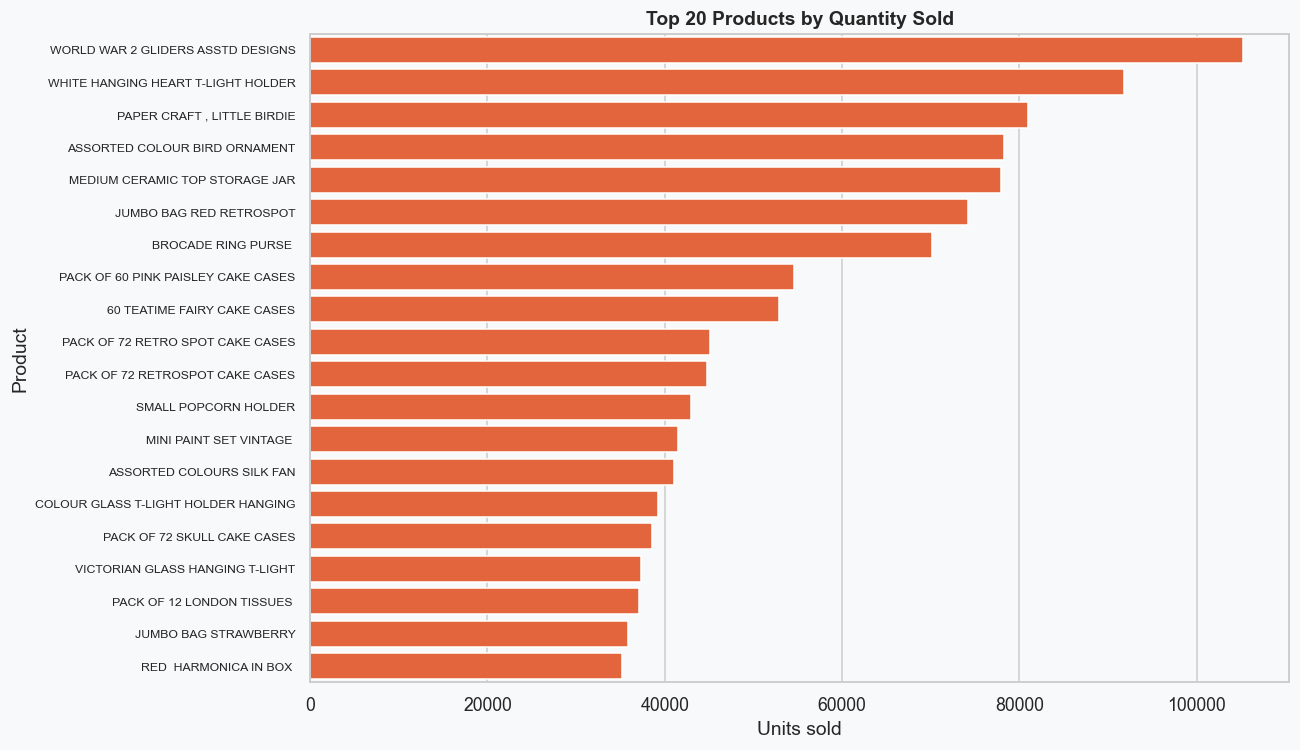


Top 10 Products by Quantity:


,Description,TotalQuantity,TotalRevenue,UniqueCustomers,AvgPrice
4031,WORLD WAR 2 GLIDERS ASSTD DESIGNS,105185,"24,098.03",482,0.26
4751,WHITE HANGING HEART T-LIGHT HOLDER,91757,"247,048.01",1490,2.87
3283,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60",1,2.08
4456,ASSORTED COLOUR BIRD ORNAMENT,78234,"124,351.86",1010,1.68
2781,MEDIUM CERAMIC TOP STORAGE JAR,77916,"81,416.73",138,1.22
4725,JUMBO BAG RED RETROSPOT,74224,"134,307.44",860,1.97
115,BROCADE RING PURSE,70082,"14,640.96",215,0.27
1357,PACK OF 60 PINK PAISLEY CAKE CASES,54592,"26,407.35",767,0.54
4595,60 TEATIME FAIRY CAKE CASES,52828,"25,785.92",822,0.54
658,PACK OF 72 RETRO SPOT CAKE CASES,45129,"21,838.23",632,0.54


In [44]:
# ── 6.2 Top 20 products by quantity sold ──────────────────────────────────────
top20_qty = product_stats.nlargest(20, 'TotalQuantity')

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=top20_qty, x='TotalQuantity', y='Description', ax=ax, color=ACCENT2)
ax.set_title('Top 20 Products by Quantity Sold', fontweight='bold')
ax.set_xlabel('Units sold')
ax.set_ylabel('Product')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

print('\nTop 10 Products by Quantity:')
display(top20_qty[['Description', 'TotalQuantity', 'TotalRevenue', 'UniqueCustomers', 'AvgPrice']].head(10))

#### Nhận xét chi tiết về top products

- Nhóm dẫn đầu doanh thu là các SKU trang trí và quà tặng gia dụng quen thuộc, nổi bật nhất là `REGENCY CAKESTAND 3 TIER` với khoảng `£277.7K`, tiếp theo là `WHITE HANGING HEART T-LIGHT HOLDER` với khoảng `£247.0K`.
- Sản phẩm bán nhiều chưa chắc tạo ra nhiều doanh thu. `WORLD WAR 2 GLIDERS ASSTD DESIGNS` dẫn đầu về số lượng (`105,185` units) nhưng doanh thu chỉ khoảng `£24.1K`, cho thấy đây là item giá rẻ dùng để kéo volume.
- `WHITE HANGING HEART T-LIGHT HOLDER` xuất hiện ở cả top revenue lẫn top quantity và có `1,490` khách hàng mua, nên đây là SKU vừa rộng tệp vừa tạo doanh thu tốt, phù hợp làm anchor product.
- `PAPER CRAFT , LITTLE BIRDIE` đạt doanh thu rất cao và số lượng lớn nhưng chỉ gắn với `1` khách hàng. Đây nhiều khả năng là giao dịch wholesale/outlier, cần tách riêng khi làm forecasting hoặc recommendation để tránh làm lệch mô hình.
- Mức độ tập trung doanh thu theo SKU không quá cao: top 10 sản phẩm chỉ chiếm khoảng `8.57%` doanh thu và top 20 chiếm `11.85%`. Danh mục bán hàng mang tính long-tail rõ rệt.

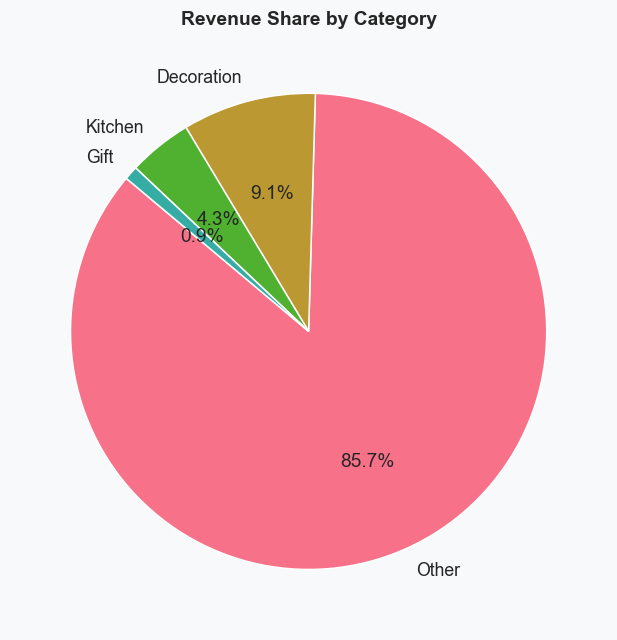

In [45]:
# ── 6.3 Revenue share by product category ──────────────────────────────────────
cat_rev = (
    df_sales.groupby('ProductCategory')['TotalValue']
    .sum()
    .sort_values(ascending=False)
)
cat_rev_pct = (cat_rev / cat_rev.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 6))
ax.pie(
    cat_rev.values,
    labels=cat_rev.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white'}
)
ax.set_title('Revenue Share by Category', fontweight='bold')
plt.tight_layout()
plt.show()

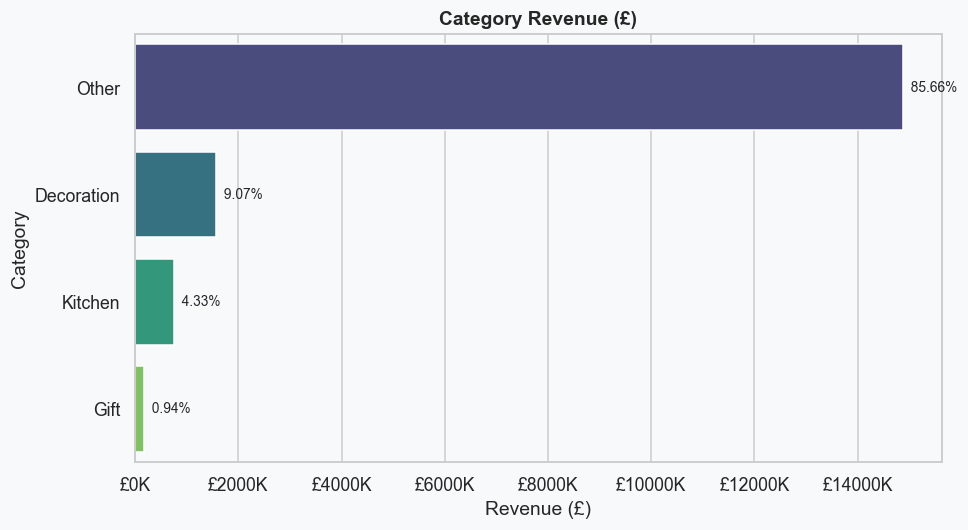

In [46]:
# ── 6.4 Category revenue bar chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=cat_rev.values, y=cat_rev.index, ax=ax, palette='viridis')
ax.set_title('Category Revenue (£)', fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.set_ylabel('Category')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

for index, value in enumerate(cat_rev.values):
    ax.text(value, index, f'  {cat_rev_pct.iloc[index]:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

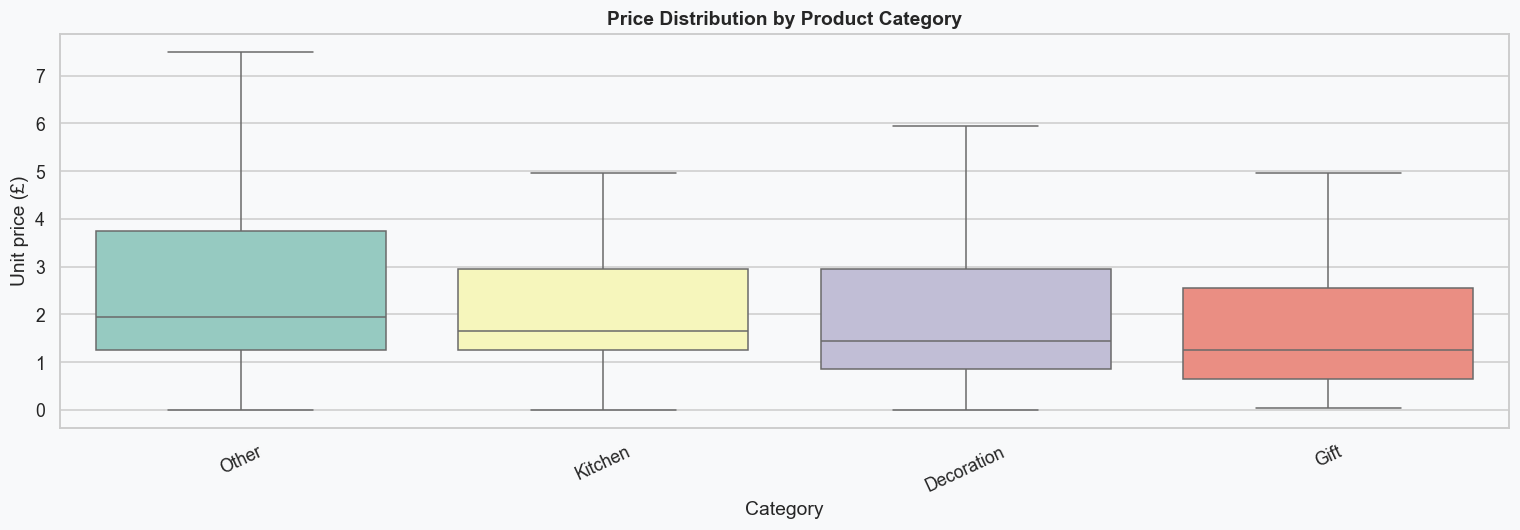

In [47]:
# ── 6.5 Price distribution by category ────────────────────────────────────────
price_cap = df_sales['Price'].quantile(0.97)
df_plot = df_sales[df_sales['Price'] <= price_cap]
order = df_plot.groupby('ProductCategory')['Price'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=df_plot,
    x='ProductCategory',
    y='Price',
    order=order,
    palette='Set3',
    ax=ax,
    showfliers=False,
)
ax.set_title('Price Distribution by Product Category', fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Unit price (£)')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

#### Nhận xét chi tiết theo category và price band

- `Other` đang chiếm tới `85.66%` doanh thu, trong khi `Decoration` chỉ `9.07%`, `Kitchen` `4.33%` và `Gift` `0.94%`. Điều này cho thấy cột `ProductCategory` hiện khá thô; nếu dùng trực tiếp cho modeling thì sức phân biệt sẽ thấp.
- Median unit price ở mọi category đều thấp, chỉ dao động từ `£1.25` đến `£1.95`. Đây là cấu trúc kinh doanh low-ticket, nên tăng doanh thu chủ yếu đến từ tăng frequency, basket size hoặc mix sản phẩm chứ không phải tăng giá đơn vị.
- `Gift` có median thấp (`£1.25`) nhưng mean cao hơn nhiều (`£3.05`), ám chỉ có một số SKU giá cao kéo đuôi phải. Category này có thể chứa các item premium nhưng quy mô hiện còn nhỏ.
- Vì category revenue đang dồn mạnh vào `Other`, nên các đặc trưng chi tiết hơn như `StockCode`, cụm mô tả sản phẩm, hoặc hành vi đồng mua sẽ hữu ích hơn nhiều so với category tổng quát.

---
## 7. Phân tích địa lý (Geographic Analysis)

In [48]:
# ── 7.1 Country performance ───────────────────────────────────────────────────
country_stats = (
    df_sales.groupby('Country')
    .agg(
        Revenue         = ('TotalValue', 'sum'),
        Orders          = ('Invoice',    'nunique'),
        Customers       = ('Customer ID','nunique'),
    )
    .reset_index()
)
country_stats['AOV'] = country_stats['Revenue'] / country_stats['Orders']
country_stats = country_stats.sort_values('Revenue', ascending=False)

print('Top 15 Countries by Revenue:')
display(
    country_stats.head(15)
    .style
    .format({'Revenue': '£{:,.0f}', 'AOV': '£{:,.2f}', 'Orders': '{:,.0f}', 'Customers': '{:,.0f}'})
    .background_gradient(subset=['Revenue'], cmap='Blues')
)

Top 15 Countries by Revenue:


,Country,Revenue,Orders,Customers,AOV
38,United Kingdom,"£14,389,235","33,546","5,353",£428.94
10,EIRE,"£616,571",567,5,"£1,087.43"
24,Netherlands,"£554,038",229,22,"£2,419.38"
14,Germany,"£425,020",789,107,£538.68
13,France,"£348,769",614,95,£568.03
0,Australia,"£169,283",95,15,"£1,781.93"
32,Spain,"£108,332",154,41,£703.46
34,Switzerland,"£100,062",90,22,"£1,111.80"
33,Sweden,"£91,516",104,19,£879.96
9,Denmark,"£68,581",43,12,"£1,594.90"


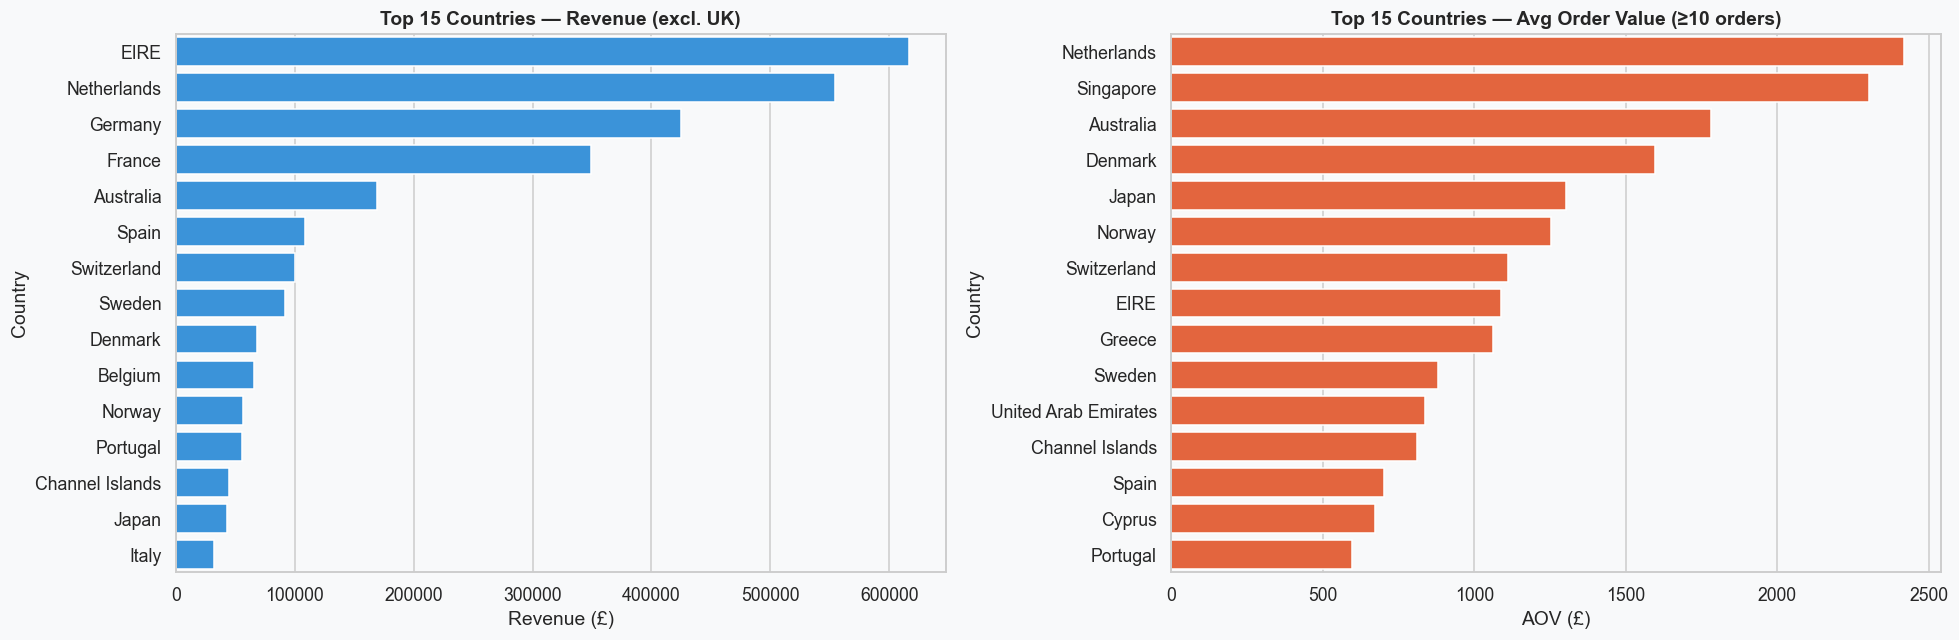

In [49]:
# ── 7.2 Geographic bar charts (exclude UK for scale) ─────────────────────────
top_excl_uk = country_stats[country_stats['Country'] != 'United Kingdom'].head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=top_excl_uk, x='Revenue', y='Country', ax=axes[0], color=ACCENT)
axes[0].set_title('Top 15 Countries — Revenue (excl. UK)', fontweight='bold')
axes[0].set_xlabel('Revenue (£)')

top_aov = country_stats[country_stats['Orders'] >= 10].nlargest(15, 'AOV')
sns.barplot(data=top_aov, x='AOV', y='Country', ax=axes[1], color=ACCENT2)
axes[1].set_title('Top 15 Countries — Avg Order Value (≥10 orders)', fontweight='bold')
axes[1].set_xlabel('AOV (£)')

plt.tight_layout()
plt.show()

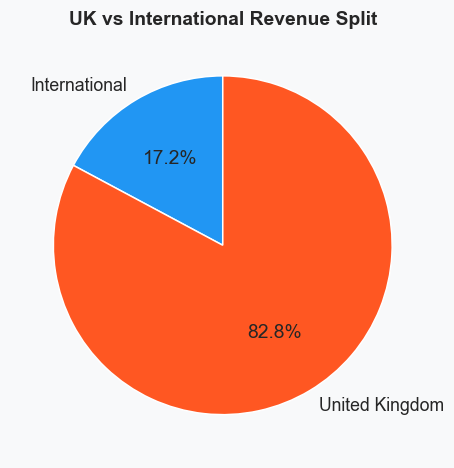

  International       : £2,985,569.35  (17.2%)
  United Kingdom      : £14,389,234.92  (82.8%)


In [50]:
# ── 7.3 UK vs International revenue split ────────────────────────────────────
df_sales['Region'] = df_sales['Country'].apply(
    lambda c: 'United Kingdom' if c == 'United Kingdom' else 'International'
)
region_rev = df_sales.groupby('Region')['TotalValue'].sum()

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(region_rev.values, labels=region_rev.index,
       autopct='%1.1f%%', colors=[ACCENT, ACCENT2],
       startangle=90, wedgeprops={'edgecolor':'white'})
ax.set_title('UK vs International Revenue Split', fontweight='bold')
plt.show()

for r, v in region_rev.items():
    print(f'  {r:<20}: £{v:>12,.2f}  ({v/region_rev.sum()*100:.1f}%)')

---
## 8. Phân tích hàng trả (Returns Analysis)

In [51]:
# ── 8.1 Return metrics ────────────────────────────────────────────────────────
ret_rev    = abs(df_returns['TotalValue'].sum())
sales_rev  = df_sales['TotalValue'].sum()
ret_pct    = ret_rev / sales_rev * 100

print(f'Total Returns Value : £{ret_rev:>12,.2f}')
print(f'Gross Sales Value   : £{sales_rev:>12,.2f}')
print(f'Return Rate (value) : {ret_pct:>11.2f}%')
print(f'Return Rows         : {len(df_returns):>12,}  ({len(df_returns)/len(df)*100:.2f}% of rows)')

Total Returns Value : £1,084,812.98
Gross Sales Value   : £17,374,804.27
Return Rate (value) :        6.24%
Return Rows         :       18,390  (2.30% of rows)


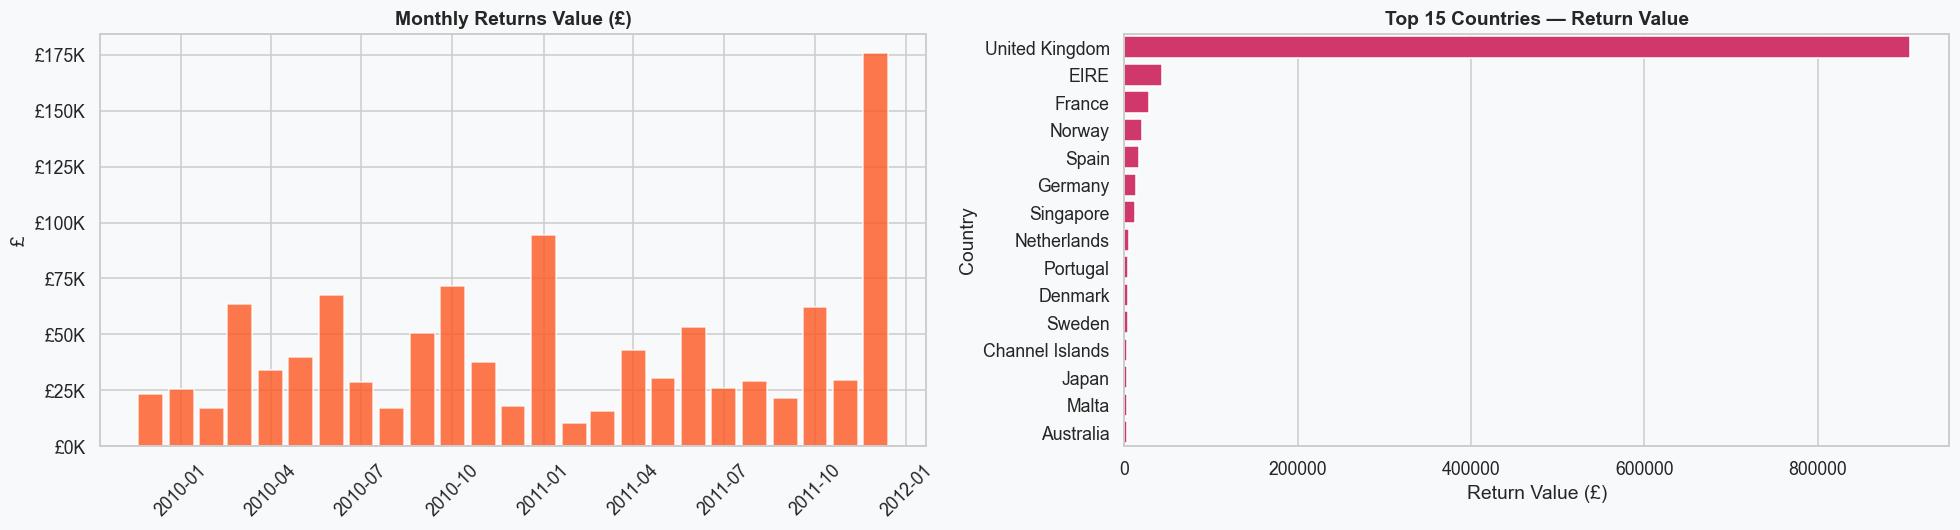

In [52]:
# ── 8.2 Returns over time & by country ───────────────────────────────────────
monthly_returns = (
    df_returns.groupby(['Year','Month'])
    .agg(ReturnValue=('TotalValue','sum'), ReturnRows=('Invoice','count'))
    .reset_index()
)
monthly_returns['ReturnValue'] = monthly_returns['ReturnValue'].abs()
monthly_returns['Date'] = pd.to_datetime(monthly_returns[['Year','Month']].assign(day=1))

country_returns = (
    df_returns.groupby('Country')['TotalValue']
    .sum().abs()
    .sort_values(ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(monthly_returns['Date'], monthly_returns['ReturnValue'], width=25, color=ACCENT2, alpha=0.8)
axes[0].set_title('Monthly Returns Value (£)', fontweight='bold')
axes[0].set_ylabel('£')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=country_returns.values, y=country_returns.index, ax=axes[1], color='#E91E63')
axes[1].set_title('Top 15 Countries — Return Value', fontweight='bold')
axes[1].set_xlabel('Return Value (£)')

plt.tight_layout()
plt.show()

---
## 9. Cohort Preview

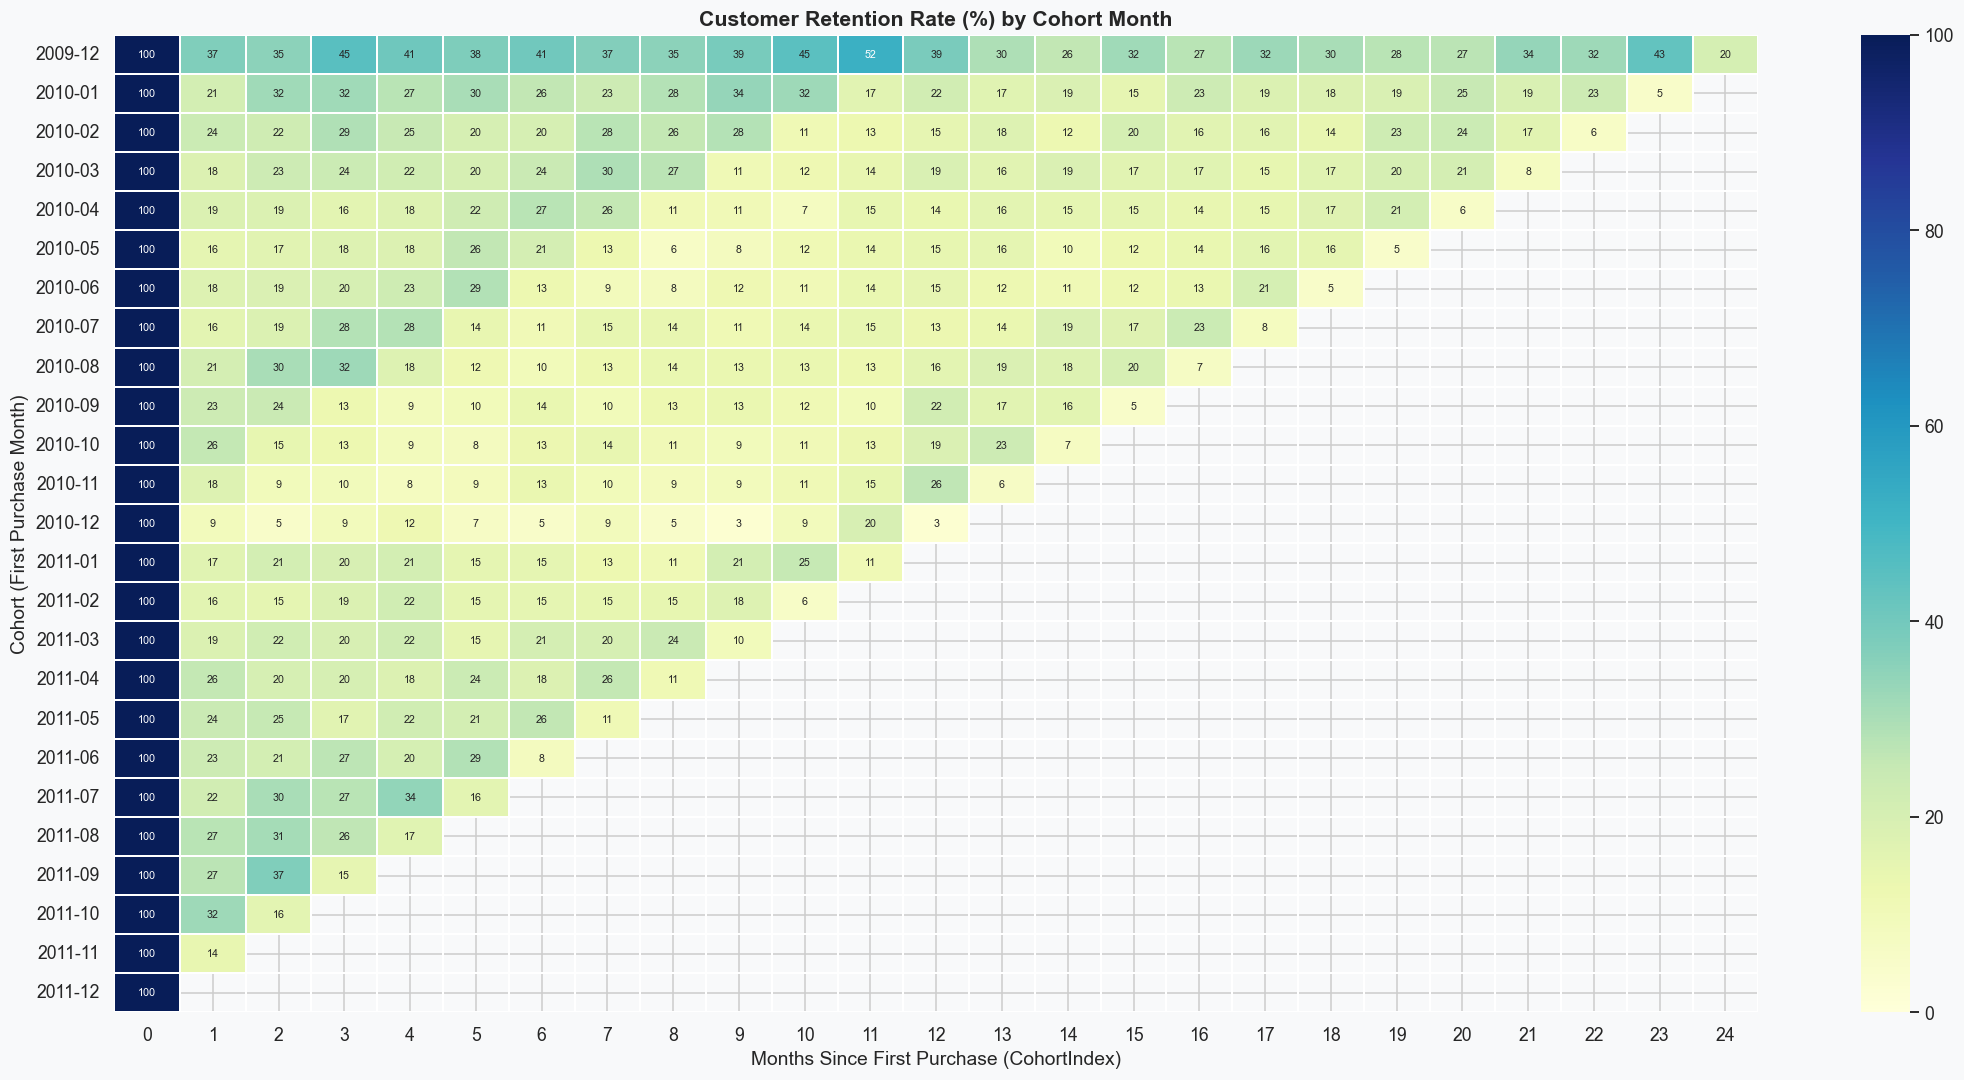


Average Retention Rate by Period:
CohortIndex
0    100.00
1     21.30
2     22.10
3     21.80
4     20.70
5     19.00
6     18.00
7     17.80
8     15.80
9     15.70
10    15.40
11    16.70
12    18.20


In [53]:
# ── 9.1 Cohort retention heatmap ──────────────────────────────────────────────
cohort_table = (
    df_sales.groupby(['CohortMonthYear','CohortIndex'])['Customer ID']
    .nunique()
    .unstack('CohortIndex')
)

# Retention rate relative to cohort size
cohort_size   = cohort_table.iloc[:, 0]
retention_pct = cohort_table.divide(cohort_size, axis=0) * 100

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(
    retention_pct,
    annot=True, fmt='.0f', cmap='YlGnBu',
    linewidths=0.3, ax=ax, annot_kws={'size': 7},
    vmin=0, vmax=100
)
ax.set_title('Customer Retention Rate (%) by Cohort Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase (CohortIndex)')
ax.set_ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.show()

# Average retention across all cohorts
avg_retention = retention_pct.mean().round(1)
print('\nAverage Retention Rate by Period:')
print(avg_retention.head(13).to_string())

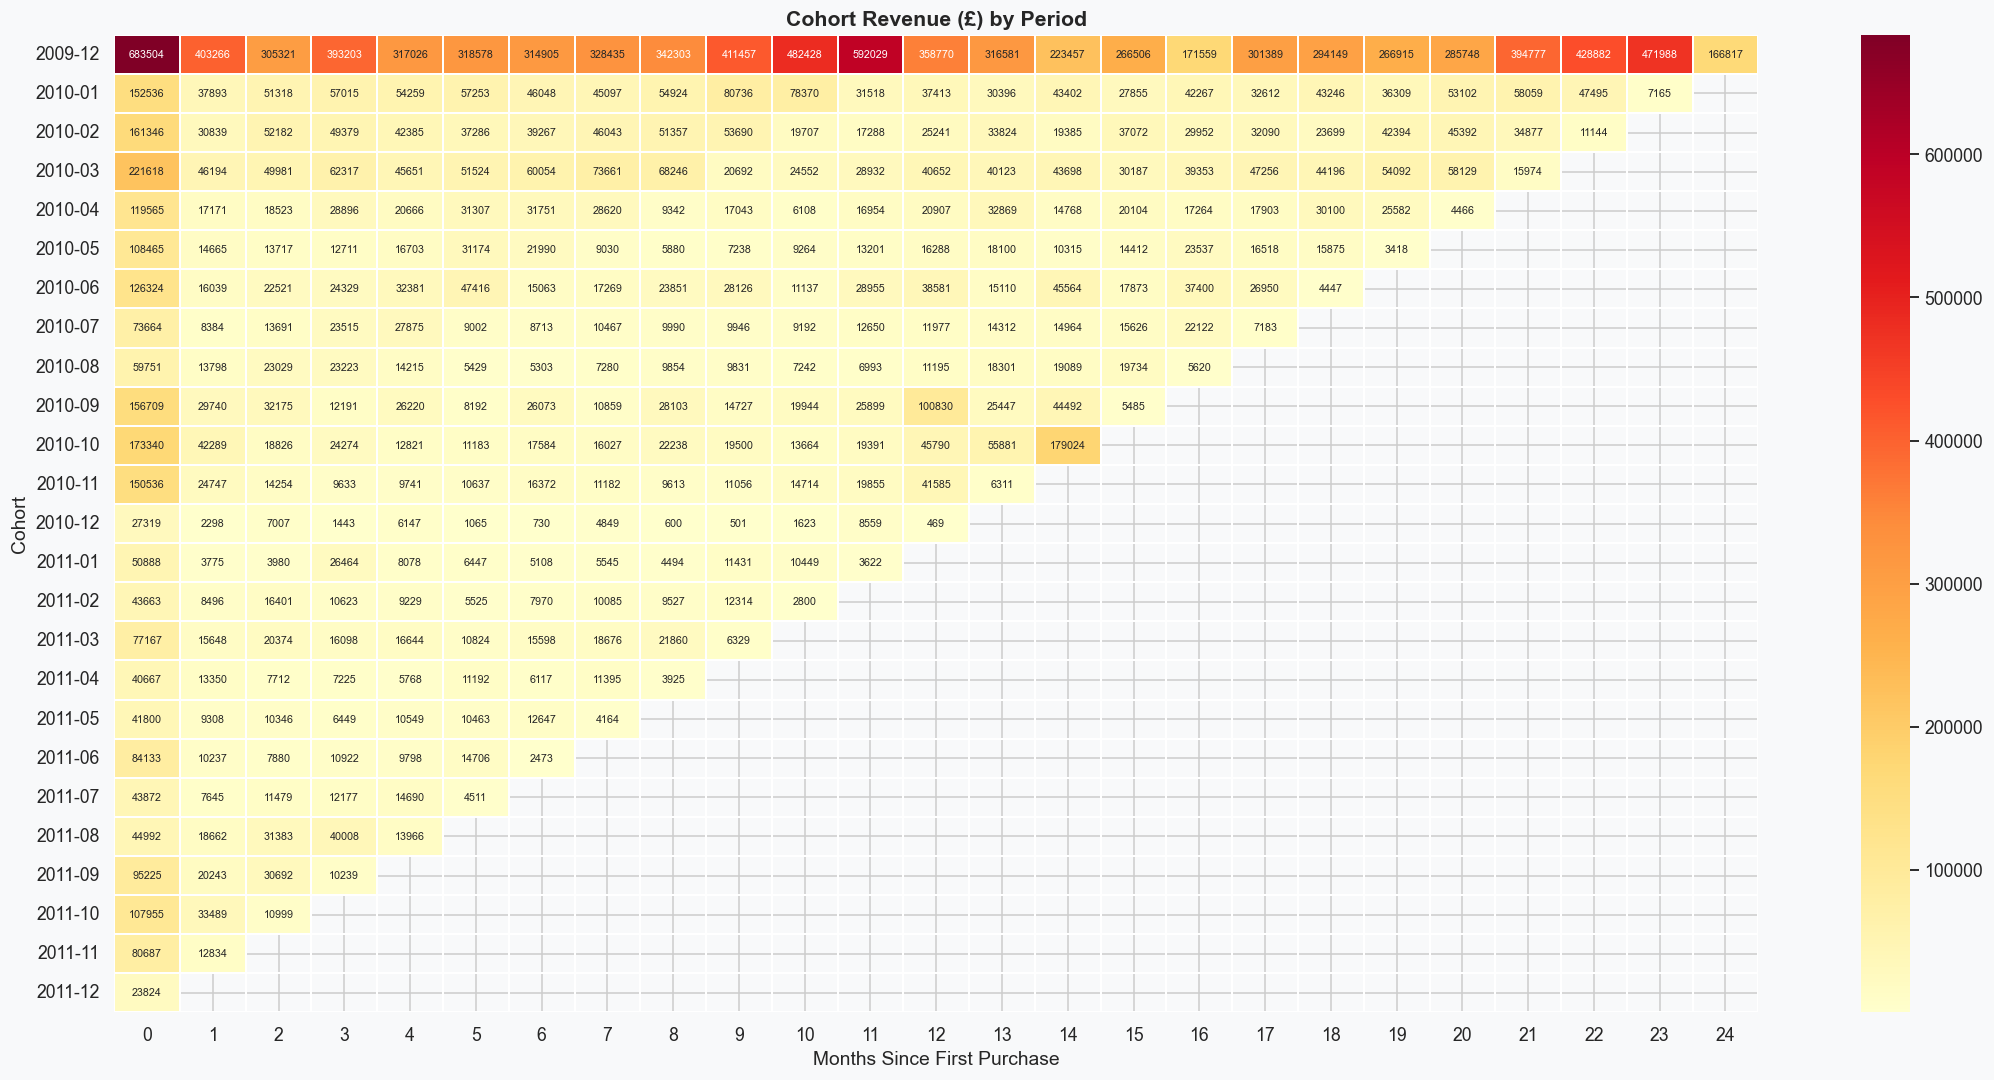

In [54]:
# ── 9.2 Cohort revenue heatmap ────────────────────────────────────────────────
cohort_rev = (
    df_sales.groupby(['CohortMonthYear','CohortIndex'])['TotalValue']
    .sum()
    .unstack('CohortIndex')
)

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(
    cohort_rev,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.3, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Cohort Revenue (£) by Period', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort')
plt.tight_layout()
plt.show()

---
## 10. Correlation Analysis & Key Insights

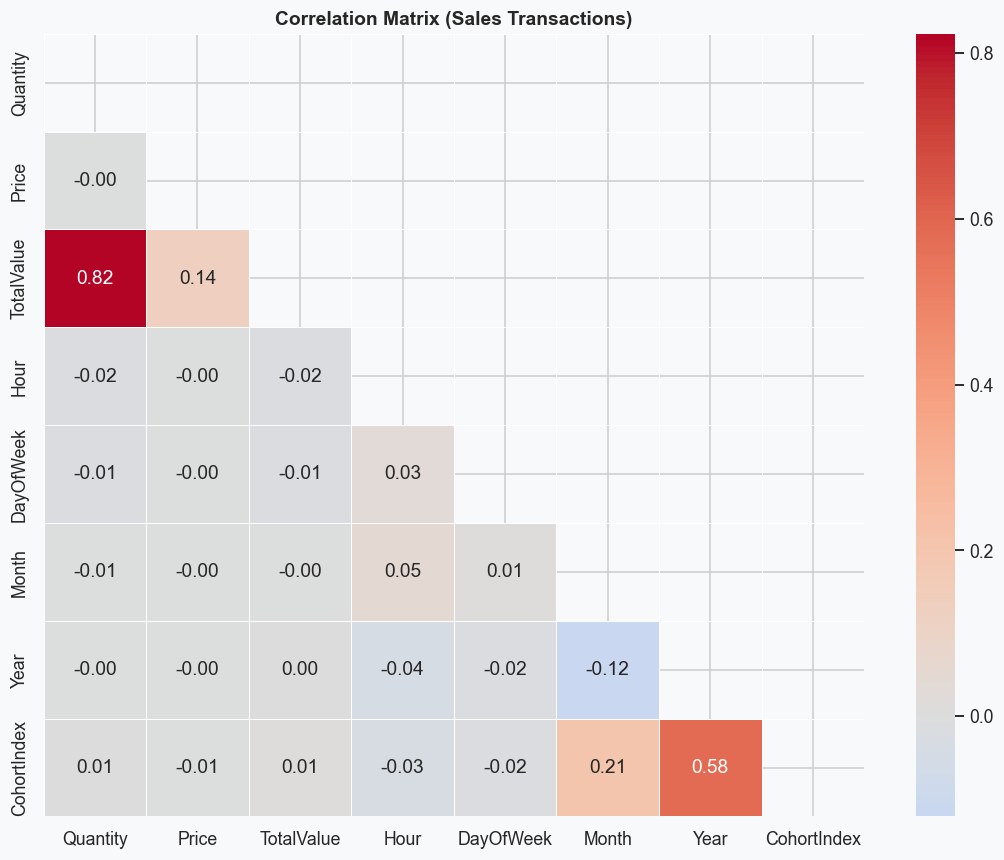

In [55]:
# ── 10.1 Correlation matrix ──────────────────────────────────────────────────
numeric_cols = ['Quantity','Price','TotalValue','Hour','DayOfWeek','Month','Year','CohortIndex']
corr = df_sales[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (Sales Transactions)', fontweight='bold')
plt.tight_layout()
plt.show()

In [56]:
# ── 10.2 Summary of Key Insights ─────────────────────────────────────────────
print('=' * 65)
print('  KEY EDA INSIGHTS')
print('=' * 65)

# Revenue
print(f'\n📦 REVENUE')
print(f'   Gross Revenue   : £{df_sales["TotalValue"].sum():>12,.0f}')
print(f'   Net Revenue     : £{df_sales["TotalValue"].sum() - abs(df_returns["TotalValue"].sum()):>12,.0f}')
print(f'   Avg Order Value : £{df_sales["TotalValue"].sum()/df_sales["Invoice"].nunique():>12,.2f}')

# Best month
best_month = monthly['TotalValue'].idxmax()
best_val   = monthly.loc[best_month, 'TotalValue']
best_label = monthly.loc[best_month, 'Date'].strftime('%b %Y')
print(f'\n📅 TIME PATTERNS')
print(f'   Best month      : {best_label} → £{best_val:,.0f}')
print(f'   Peak weekday    : {dow_rev.idxmax()} (£{dow_rev.max():,.0f})')
print(f'   Peak hour       : {hour_rev.idxmax()}:00  (£{hour_rev.max():,.0f})')

# Customers
champions   = rfm[rfm['Segment']=='Champions']
champion_pct= len(champions)/len(rfm)*100
print(f'\n👥 CUSTOMERS')
print(f'   Total customers : {len(rfm):>12,}')
print(f'   Champions (5/5) : {len(champions):>12,}  ({champion_pct:.1f}%)')
print(f'   Avg recency     : {rfm["Recency"].mean():>11.0f}d')
print(f'   Avg frequency   : {rfm["Frequency"].mean():>11.1f} orders')
print(f'   Avg monetary    : £{rfm["Monetary"].mean():>11,.2f}')

# Products
top_product = top20_rev.iloc[0]
print(f'\n🛍  PRODUCTS')
print(f'   Unique products : {df_sales["StockCode"].nunique():>12,}')
print(f'   Top product     : {top_product["Description"]}')
print(f'   Top revenue     : £{top_product["TotalRevenue"]:>10,.2f}')

# Geography
uk_rev  = country_stats[country_stats['Country']=='United Kingdom']['Revenue'].values[0]
all_rev = country_stats['Revenue'].sum()
print(f'\n🌍 GEOGRAPHY')
print(f'   UK revenue share: {uk_rev/all_rev*100:.1f}%')
print(f'   Countries served: {df_sales["Country"].nunique()}')
print(f'   Top intl market : {country_stats[country_stats["Country"]!="United Kingdom"].iloc[0]["Country"]}')

print('\n' + '=' * 65)

  KEY EDA INSIGHTS

📦 REVENUE
   Gross Revenue   : £  17,374,804
   Net Revenue     : £  16,289,991
   Avg Order Value : £      469.91

📅 TIME PATTERNS
   Best month      : Nov 2010 → £1,166,460
   Peak weekday    : Thursday (£3,745,783)
   Peak hour       : 12:00  (£2,690,584)

👥 CUSTOMERS
   Total customers :        5,881
   Champions (5/5) :        1,482  (25.2%)
   Avg recency     :         201d
   Avg frequency   :         6.3 orders
   Avg monetary    : £   2,954.40

🛍  PRODUCTS
   Unique products :        4,631
   Top product     : REGENCY CAKESTAND 3 TIER
   Top revenue     : £277,656.25

🌍 GEOGRAPHY
   UK revenue share: 82.8%
   Countries served: 41
   Top intl market : EIRE



## 11. Forecasting Baseline and Transformer Benchmark Hooks
Mục tiêu của phần này:
- Tạo benchmark baseline cho dự báo doanh thu.
- Chuẩn bị khung thử nghiệm Transformer dạng non-blocking.
- Đồng bộ schema đánh giá để so sánh công bằng giữa các mô hình.

In [57]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)

DATE_COL = "InvoiceDate"
TARGET_COL = "TotalValue"
FREQ = "MS"
VAL_HORIZON = 3

print("Forecast benchmark config loaded")
print(f"- date col: {DATE_COL}")
print(f"- target col: {TARGET_COL}")
print(f"- frequency: {FREQ}")
print(f"- validation horizon: {VAL_HORIZON}")

Forecast benchmark config loaded
- date col: InvoiceDate
- target col: TotalValue
- frequency: MS
- validation horizon: 3


In [58]:
def build_monthly_revenue_table(df_sales: pd.DataFrame) -> pd.DataFrame:
    df_tmp = df_sales.copy()
    df_tmp[DATE_COL] = pd.to_datetime(df_tmp[DATE_COL], errors="coerce")
    monthly = (
        df_tmp.dropna(subset=[DATE_COL])
        .assign(month=lambda x: x[DATE_COL].dt.to_period("M").dt.to_timestamp())
        .groupby("month", as_index=False)[TARGET_COL]
        .sum()
        .rename(columns={"month": "ds", TARGET_COL: "y"})
        .sort_values("ds")
    )

    if monthly.empty:
        raise ValueError("No valid monthly data available after InvoiceDate parsing.")

    full_idx = pd.date_range(monthly["ds"].min(), monthly["ds"].max(), freq=FREQ)
    monthly = (
        monthly.set_index("ds")
        .reindex(full_idx)
        .rename_axis("ds")
        .reset_index()
    )
    monthly["y"] = monthly["y"].fillna(0.0)
    monthly["t"] = np.arange(len(monthly))
    return monthly


def split_time_series(df_ts: pd.DataFrame, horizon: int = VAL_HORIZON):
    if len(df_ts) <= horizon:
        raise ValueError("Time series is too short for the selected validation horizon.")
    train_df = df_ts.iloc[:-horizon].copy()
    val_df = df_ts.iloc[-horizon:].copy()
    return train_df, val_df


df_ts = build_monthly_revenue_table(df_sales)
train_df, val_df = split_time_series(df_ts, VAL_HORIZON)

print("Monthly table prepared")
print(f"- train range: {train_df['ds'].min().date()} -> {train_df['ds'].max().date()} ({len(train_df)} rows)")
print(f"- val range:   {val_df['ds'].min().date()} -> {val_df['ds'].max().date()} ({len(val_df)} rows)")

Monthly table prepared
- train range: 2009-12-01 -> 2011-09-01 (22 rows)
- val range:   2011-10-01 -> 2011-12-01 (3 rows)


In [59]:
def naive_last(train_df: pd.DataFrame, horizon: int) -> np.ndarray:
    return np.repeat(train_df["y"].iloc[-1], horizon)


def seasonal_naive_12(train_df: pd.DataFrame, horizon: int) -> np.ndarray:
    season_len = 12
    if len(train_df) >= season_len:
        base = train_df["y"].iloc[-season_len:]
        reps = int(np.ceil(horizon / season_len))
        return np.tile(base.values, reps)[:horizon]
    return naive_last(train_df, horizon)


def moving_average_3(train_df: pd.DataFrame, horizon: int) -> np.ndarray:
    window = min(3, len(train_df))
    return np.repeat(train_df["y"].tail(window).mean(), horizon)


def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    safe = np.where(denominator == 0, 1e-8, denominator)
    return float(np.mean(np.abs(y_true - y_pred) / safe) * 100)


def evaluate_forecast(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "sMAPE": smape(y_true, y_pred),
    }


def run_baseline_benchmarks(train_df: pd.DataFrame, val_df: pd.DataFrame) -> pd.DataFrame:
    y_true = val_df["y"].values
    horizon = len(val_df)

    candidates = {
        "naive_last": naive_last(train_df, horizon),
        "seasonal_naive_12": seasonal_naive_12(train_df, horizon),
        "moving_average_3": moving_average_3(train_df, horizon),
    }

    rows = []
    for model_name, preds in candidates.items():
        metrics = evaluate_forecast(y_true, preds)
        rows.append({
            "model": model_name,
            "status": "ok",
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "sMAPE": metrics["sMAPE"],
            "notes": "baseline",
        })
    return pd.DataFrame(rows).sort_values("RMSE")

baseline_results = run_baseline_benchmarks(train_df, val_df)
baseline_results

,model,status,MAE,RMSE,sMAPE,notes
1,seasonal_naive_12,ok,"21,999.71","31,322.61",3.64,baseline
0,naive_last,ok,"241,316.47","281,282.72",29.04,baseline
2,moving_average_3,ok,"314,468.30","326,124.50",37.93,baseline


In [60]:
def run_transformer_benchmark_hook(train_df: pd.DataFrame, val_df: pd.DataFrame) -> pd.DataFrame:
    y_true = val_df["y"].values
    horizon = len(val_df)

    try:
        import torch  # noqa: F401
        from torch import nn  # noqa: F401

        # Lightweight placeholder policy:
        # use a weighted blend of last value and rolling mean as a proxy while
        # wiring the benchmark API. Replace this with a real transformer trainer
        # in the dedicated modeling notebook.
        last_val = train_df["y"].iloc[-1]
        mean_3 = train_df["y"].tail(min(3, len(train_df))).mean()
        preds = np.repeat(0.6 * last_val + 0.4 * mean_3, horizon)

        metrics = evaluate_forecast(y_true, preds)
        return pd.DataFrame([
            {
                "model": "transformer_hook",
                "status": "ok",
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
                "sMAPE": metrics["sMAPE"],
                "notes": "hook active; replace with full transformer training in advanced modeling notebook",
            }
        ])

    except Exception as ex:
        return pd.DataFrame([
            {
                "model": "transformer_hook",
                "status": "skipped",
                "MAE": np.nan,
                "RMSE": np.nan,
                "sMAPE": np.nan,
                "notes": f"transformer libs unavailable: {type(ex).__name__}",
            }
        ])


def run_benchmark_suite(include_transformer: bool = True) -> pd.DataFrame:
    results = [run_baseline_benchmarks(train_df, val_df)]
    if include_transformer:
        results.append(run_transformer_benchmark_hook(train_df, val_df))
    out = pd.concat(results, ignore_index=True)
    return out.sort_values(["status", "RMSE"], na_position="last")

benchmark_results = run_benchmark_suite(include_transformer=True)
benchmark_results

,model,status,MAE,RMSE,sMAPE,notes
0,seasonal_naive_12,ok,"21,999.71","31,322.61",3.64,baseline
1,naive_last,ok,"241,316.47","281,282.72",29.04,baseline
2,moving_average_3,ok,"314,468.30","326,124.50",37.93,baseline
3,transformer_hook,skipped,NaN,NaN,NaN,transformer libs unavailable: ModuleNotFoundError


---
## 12. Phân tích B2B / B2C (Business Model Split)

Phần này phân loại khách hàng thành hai nhóm:
- **B2B / Account-like**: Khách hàng mua số lượng lớn, tần suất cao, giá trị đơn hàng cao — đặc trưng của mô hình bán buôn/đại lý.
- **B2C / Consumer-like**: Khách hàng mua lẻ, số lượng nhỏ, giá trị thấp hơn — đặc trưng của người tiêu dùng cuối.

Logic phân loại dựa trên 4 tín hiệu:
1. `avg_units_per_invoice` >= Q90
2. `total_units` >= Q90
3. `avg_order_value` >= Q85
4. `monetary` >= Q90 AND `distinct_invoices` >= Q80

Nếu >= 2 tín hiệu đúng → **B2B**, ngược lại → **B2C**.

In [ ]:
# ── 12.1 Build customer-level features for B2B/B2C classification ────────────
snapshot_date_b2b = df['InvoiceDate'].max() + pd.Timedelta(days=1)
window_start = snapshot_date_b2b - pd.Timedelta(days=90)

sales_90d = df_sales[
    (df_sales['InvoiceDate'] >= window_start) &
    (df_sales['InvoiceDate'] < snapshot_date_b2b)
].copy()

# Customer-level aggregation
cust_agg = (
    sales_90d.groupby('Customer ID')
    .agg(
        monetary_90d=('TotalValue', 'sum'),
        frequency_90d=('Invoice', 'nunique'),
        total_units_90d=('Quantity', 'sum'),
        distinct_products_90d=('StockCode', 'nunique'),
        distinct_invoices_90d=('Invoice', 'nunique'),
    )
    .reset_index()
)

# Avg order value per customer
order_aov = (
    sales_90d.groupby(['Customer ID', 'Invoice'])['TotalValue']
    .sum()
    .groupby('Customer ID')
    .mean()
    .rename('avg_order_value_90d')
)
cust_agg = cust_agg.merge(order_aov, on='Customer ID', how='left')

# Avg units per invoice
invoice_units = (
    sales_90d.groupby(['Customer ID', 'Invoice'])['Quantity']
    .sum()
    .groupby('Customer ID')
    .mean()
    .rename('avg_units_per_invoice_90d')
)
cust_agg = cust_agg.merge(invoice_units, on='Customer ID', how='left')

# Also merge Recency from RFM table
cust_agg = cust_agg.merge(rfm[['Customer ID', 'Recency', 'Monetary', 'Segment']], on='Customer ID', how='left')

print(f"Customers with 90-day activity: {len(cust_agg):,}")
display(cust_agg.head())

In [ ]:
# ── 12.2 Classify B2B vs B2C ─────────────────────────────────────────────────
# Quantile thresholds
units_invoice_q90 = cust_agg['avg_units_per_invoice_90d'].quantile(0.90)
units_total_q90   = cust_agg['total_units_90d'].quantile(0.90)
aov_q85           = cust_agg['avg_order_value_90d'].quantile(0.85)
monetary_q90      = cust_agg['monetary_90d'].quantile(0.90)
invoices_q80      = cust_agg['distinct_invoices_90d'].quantile(0.80)

def assign_customer_model(row):
    b2b_signals = 0
    if row['avg_units_per_invoice_90d'] >= units_invoice_q90:
        b2b_signals += 1
    if row['total_units_90d'] >= units_total_q90:
        b2b_signals += 1
    if row['avg_order_value_90d'] >= aov_q85:
        b2b_signals += 1
    if row['monetary_90d'] >= monetary_q90 and row['distinct_invoices_90d'] >= invoices_q80:
        b2b_signals += 1
    return 'B2B / Account-like' if b2b_signals >= 2 else 'B2C / Consumer-like'

cust_agg['customer_model'] = cust_agg.apply(assign_customer_model, axis=1)

# Summary statistics
model_summary = (
    cust_agg.groupby('customer_model')
    .agg(
        customers=('Customer ID', 'nunique'),
        median_monetary=('monetary_90d', 'median'),
        median_frequency=('frequency_90d', 'median'),
        median_aov=('avg_order_value_90d', 'median'),
        median_units_per_invoice=('avg_units_per_invoice_90d', 'median'),
    )
)
model_summary['share_pct'] = (model_summary['customers'] / model_summary['customers'].sum() * 100).round(2)

print("═" * 50)
print("  B2B vs B2C Classification Summary")
print("═" * 50)
display(model_summary.reset_index())

print(f"\nThresholds used:")
print(f"  units_per_invoice Q90 = {units_invoice_q90:,.1f}")
print(f"  total_units Q90       = {units_total_q90:,.0f}")
print(f"  AOV Q85               = £{aov_q85:,.2f}")
print(f"  monetary Q90          = £{monetary_q90:,.2f}")
print(f"  invoices Q80          = {invoices_q80:.0f}")

In [ ]:
# ── 12.3 Visualization: B2B vs B2C ───────────────────────────────────────────
BM_COLORS = {'B2B / Account-like': '#8b5cf6', 'B2C / Consumer-like': '#3b82f6'}

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('B2B vs B2C Customer Comparison', fontsize=15, fontweight='bold', y=1.01)

# (1) Bar chart: customer count
bm_counts = cust_agg['customer_model'].value_counts()
bars = axes[0, 0].bar(bm_counts.index, bm_counts.values,
                       color=[BM_COLORS[k] for k in bm_counts.index],
                       edgecolor='white', width=0.5)
axes[0, 0].set_title('Customer Count by Business Model', fontweight='bold')
axes[0, 0].set_ylabel('Customers')
for bar, val in zip(bars, bm_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, val + 20,
                     f'{val:,} ({val/len(cust_agg)*100:.1f}%)',
                     ha='center', fontsize=10, fontweight='bold')

# (2) Box plot: Monetary (90d)
b2b_m = cust_agg.loc[cust_agg['customer_model'] == 'B2B / Account-like', 'monetary_90d']
b2c_m = cust_agg.loc[cust_agg['customer_model'] == 'B2C / Consumer-like', 'monetary_90d']
# Cap at 95th percentile for visibility
cap = cust_agg['monetary_90d'].quantile(0.95)
bp = axes[0, 1].boxplot(
    [b2b_m.clip(upper=cap), b2c_m.clip(upper=cap)],
    labels=['B2B', 'B2C'],
    patch_artist=True,
    widths=0.4,
)
for patch, color in zip(bp['boxes'], [BM_COLORS['B2B / Account-like'], BM_COLORS['B2C / Consumer-like']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 1].set_title('Monetary (90d) — capped 95th pct', fontweight='bold')
axes[0, 1].set_ylabel('£')
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# (3) Box plot: Frequency (90d)
b2b_f = cust_agg.loc[cust_agg['customer_model'] == 'B2B / Account-like', 'frequency_90d']
b2c_f = cust_agg.loc[cust_agg['customer_model'] == 'B2C / Consumer-like', 'frequency_90d']
fcap = cust_agg['frequency_90d'].quantile(0.95)
bp2 = axes[1, 0].boxplot(
    [b2b_f.clip(upper=fcap), b2c_f.clip(upper=fcap)],
    labels=['B2B', 'B2C'],
    patch_artist=True,
    widths=0.4,
)
for patch, color in zip(bp2['boxes'], [BM_COLORS['B2B / Account-like'], BM_COLORS['B2C / Consumer-like']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_title('Frequency (90d) — capped 95th pct', fontweight='bold')
axes[1, 0].set_ylabel('Number of invoices')

# (4) RFM Segment breakdown by B2B/B2C
if 'Segment' in cust_agg.columns:
    ct = pd.crosstab(cust_agg['Segment'], cust_agg['customer_model'], normalize='columns') * 100
    ct.plot(kind='barh', ax=axes[1, 1], color=[BM_COLORS.get(c, '#999') for c in ct.columns],
            edgecolor='white', width=0.7)
    axes[1, 1].set_title('RFM Segment % within each Business Model', fontweight='bold')
    axes[1, 1].set_xlabel('% of customers')
    axes[1, 1].legend(title='Business Model', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# ── 12.4 Statistical comparison: B2B vs B2C ─────────────────────────────────
from scipy import stats

compare_cols = ['monetary_90d', 'frequency_90d', 'avg_order_value_90d',
                'avg_units_per_invoice_90d', 'total_units_90d', 'distinct_products_90d']

results = []
b2b = cust_agg[cust_agg['customer_model'] == 'B2B / Account-like']
b2c = cust_agg[cust_agg['customer_model'] == 'B2C / Consumer-like']

for col in compare_cols:
    stat, pval = stats.mannwhitneyu(b2b[col].dropna(), b2c[col].dropna(), alternative='two-sided')
    results.append({
        'Metric': col,
        'B2B_median': b2b[col].median(),
        'B2C_median': b2c[col].median(),
        'Ratio (B2B/B2C)': round(b2b[col].median() / max(b2c[col].median(), 0.01), 2),
        'U-statistic': stat,
        'p-value': pval,
        'Significant (α=0.05)': '✓' if pval < 0.05 else '✗',
    })

stat_df = pd.DataFrame(results)
print("═" * 60)
print("  Mann–Whitney U Tests: B2B vs B2C (α = 0.05)")
print("═" * 60)
display(stat_df)

In [ ]:
# ── 12.5 B2B vs B2C: Churn risk distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn Risk by Business Model', fontsize=14, fontweight='bold')

for ax, (name, grp) in zip(axes, cust_agg.groupby('customer_model')):
    color = BM_COLORS[name]
    if 'churn_risk_index' in grp.columns:
        ax.hist(grp['churn_risk_index'].dropna(), bins=30, color=color,
                alpha=0.75, edgecolor='white')
        ax.axvline(grp['churn_risk_index'].median(), color='red', ls='--', lw=1.5,
                   label=f'Median = {grp["churn_risk_index"].median():.2f}')
        ax.set_xlabel('Churn Risk Index')
    elif 'churn_probability' in grp.columns:
        ax.hist(grp['churn_probability'].dropna(), bins=30, color=color,
                alpha=0.75, edgecolor='white')
        ax.axvline(grp['churn_probability'].median(), color='red', ls='--', lw=1.5,
                   label=f'Median = {grp["churn_probability"].median():.2f}')
        ax.set_xlabel('Churn Probability')
    else:
        ax.text(0.5, 0.5, 'No churn column found', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Customers')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Quick summary table
if 'churn_risk_index' in cust_agg.columns:
    churn_col = 'churn_risk_index'
elif 'churn_probability' in cust_agg.columns:
    churn_col = 'churn_probability'
else:
    churn_col = None

if churn_col:
    churn_summary = (
        cust_agg.groupby('customer_model')[churn_col]
        .agg(['mean', 'median', 'std', lambda x: (x >= 0.5).mean()])
        .rename(columns={'mean': 'Mean', 'median': 'Median', 'std': 'Std Dev', '<lambda_0>': '% High Risk (≥0.5)'})
    )
    churn_summary['% High Risk (≥0.5)'] = (churn_summary['% High Risk (≥0.5)'] * 100).round(1)
    print(f"\n  Churn risk summary by Business Model  ({churn_col})")
    display(churn_summary)